In [ ]:
'''
=============================================================================
WellBERT: Detecting Depression and Suicidal Ideation in Social Media Text
=============================================================================

OVERVIEW
--------
This notebook implements a full NLP pipeline for three-class mental health
classification of social media posts (Normal, Depression, Suicidal).
The project evaluates ten modeling approaches — from a rule-based VADER
baseline to WellBERT, a lightweight fine-tuned BERT-base-uncased model with
weighted cross-entropy loss — on a 42,399-post dataset sourced from Reddit,
Twitter, and a chatbot corpus (Sarkar, 2024).

=============================================================================
NOTEBOOK STRUCTURE
=============================================================================

PHASE 1 — Data & EDA
---------------------
           |  Load dataset & inspect schema
           |  Class distribution & balance
           |  Word count & character count distributions (violin + CDF)
           |  BERT-aware token length distribution (512-token limit)
           |  Top word frequencies per class (after cleaning)
           |  Classical ML preprocessing pipeline
               └─ lowercase → remove URLs / punct / digits
               └─ stopword removal (retain I/me/my, not/never/cannot)
               └─ Snowball stemming
           |  Transformer preprocessing pipeline
               └─ encoding fix + URL removal only (preserves full context)
           |  Train / Validation / Test split (70/15/15, stratified)
           |  Save all figures and processed splits to ./outputs/

PHASE 2 — Baseline Models
--------------------------
           |  VADER sentiment baseline (rule-based, no training)
           |  Logistic Regression — BoW features
           |  Logistic Regression — TF-IDF features
           |  Linear SVM — TF-IDF features
           |  Naive Bayes — TF-IDF features
           |  Decision Tree — TF-IDF features
           |  Random Forest — TF-IDF features
           |  LSA + Logistic Regression (SVD 300-dim dense embeddings)
           |  Zero-shot LLM baseline (BART-large-MNLI, no fine-tuning)
           |  Baseline results table & confusion matrices

PHASE 3 — WellBERT Fine-Tuning
--------------------------------
           |  Tokenization (BertTokenizerFast, max_len=512)
           |  Dataset & DataLoader construction
           |  Model definition (bert-base-uncased + linear head)
           |  Weighted cross-entropy loss (inv-freq + 1.5x Suicidal boost)
           |  Training loop (5 epochs, AdamW, lr=1e-5, warmup 10%)
               └─ dropout p=0.1, weight decay=0.01, grad clip=1.0
               └─ checkpoint by best validation macro F1
           |  WellBERT evaluation on held-out test set

PHASE 4 — Evaluation & Analysis
---------------------------------
           |  Full 10-model results table (accuracy, macro F1, per-class F1)
           |  Depression <-> Suicidal confusion analysis (critical miss rate)
           |  Out-of-distribution (OOD) robustness testing
               └─ Anxiety · Bipolar · Stress · Personality disorder
           |  Performance by text length (short <=47 vs long >47 words)
           |  Qualitative error analysis (48 misclassified examples)
           |  Computational efficiency comparison

=============================================================================
DATASET
=============================================================================

  Source   |  Sarkar (2024) — Sentiment Analysis for Mental Health [Kaggle]
  Posts    |  42,399 total  (Reddit · Twitter · chatbot corpus)
  Classes  |  Normal      (16,343 · 38.6%)
           |  Depression  (15,404 · 36.3%)
           |  Suicidal    (10,652 · 25.1%)
  Split    |  Train 70% (29,678) · Val 15% (6,361) · Test 15% (6,360)
           |  Stratified to preserve class proportions across all splits

=============================================================================
OUTPUTS
=============================================================================

  outputs/fig1_class_distribution.png
  outputs/fig2_word_count_distributions.png
  outputs/fig3_token_length_bert.png
  outputs/fig4_top_words_per_class.png
  outputs/fig5_confusion_matrices.png
  outputs/fig6_f1_comparison.png
  outputs/fig7_dep_sui_confusion.png
  outputs/splits/X_train.npy · X_val.npy · X_test.npy
  outputs/splits/X_train_raw.npy · X_val_raw.npy · X_test_raw.npy
  outputs/splits/y_train.npy · y_val.npy · y_test.npy
  outputs/preds_vader.npy · preds_lr_bow.npy · preds_lr_tfidf.npy
  outputs/preds_svm.npy · preds_nb.npy · preds_dt.npy · preds_rf.npy
  outputs/preds_lsa.npy · preds_llm.npy · preds_bert.npy
  outputs/wellbert.pt  (best checkpoint by val macro F1)
  outputs/eda_summary.csv

=============================================================================
NOTE
=============================================================================

  Runtime → Restart and run all
  Do not re-run individual cells out of order.

=============================================================================
'''

#**EXPLORATORY DATA ANALYSIS**

In [1]:
import re, os, warnings
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from nltk.stem.snowball import SnowballStemmer
import random

os.environ["PYTHONHASHSEED"] = str(42)
random.seed(42)
np.random.seed(42)

warnings.filterwarnings("ignore")

LABEL_ORDER = ["Normal", "Depression", "Suicidal"]
COLORS      = {"Normal": "#4C9BE8", "Depression": "#F4A261", "Suicidal": "#E76F51"}
PALETTE     = [COLORS[l] for l in LABEL_ORDER]

OUT_DIR    = "/content/drive/MyDrive/BIOS735/Final/outputs"
SPLITS_DIR = OUT_DIR + "/splits"
os.makedirs(OUT_DIR,    exist_ok=True)
os.makedirs(SPLITS_DIR, exist_ok=True)

DATA_PATH = "/content/drive/MyDrive/BIOS735/Final/Combined Data.csv"

In [2]:
df_full = pd.read_csv(DATA_PATH)
df_full = df_full.rename(columns={"statement": "text", "status": "label"})
df_full = df_full.dropna(subset=["text"]).reset_index(drop=True)
df_full["text"]  = df_full["text"].astype(str)
df_full["label"] = df_full["label"].str.strip()

print("Full dataset shape:", df_full.shape)
print("All classes:", df_full["label"].value_counts().to_dict())

# Filter to the 3 target classes
df = df_full[df_full["label"].isin(LABEL_ORDER)].reset_index(drop=True)
print(f"\n3-class subset: {df.shape}")
vc = df["label"].value_counts()
for cls in LABEL_ORDER:
    print(f"  {cls:12s}: {vc[cls]:6,}  ({vc[cls]/len(df)*100:.1f}%)")

Full dataset shape: (52681, 3)
All classes: {'Normal': 16343, 'Depression': 15404, 'Suicidal': 10652, 'Anxiety': 3841, 'Bipolar': 2777, 'Stress': 2587, 'Personality disorder': 1077}

3-class subset: (42399, 3)
  Normal      : 16,343  (38.5%)
  Depression  : 15,404  (36.3%)
  Suicidal    : 10,652  (25.1%)


In [ ]:
df["word_count"]   = df["text"].str.split().str.len()
df["char_count"]   = df["text"].str.len()
df["avg_word_len"] = df["char_count"] / df["word_count"].replace(0, np.nan)

print("Word count statistics per class:")
print(
    df.groupby("label")["word_count"]
      .describe()[["count","mean","50%","std","min","max"]]
      .rename(columns={"50%":"median"})
      .astype({"count": int})
      .round(1)
      .loc[LABEL_ORDER]
)
df.groupby("label")["word_count"].describe().to_csv(OUT_DIR + "/eda_summary.csv")

Word count statistics per class:
            count   mean  median    std  min     max
label                                               
Normal      16343   17.2    10.0   22.8  1.0   255.0
Depression  15404  168.0   113.0  188.2  1.0  4239.0
Suicidal    10652  146.4    92.0  187.0  1.0  6300.0


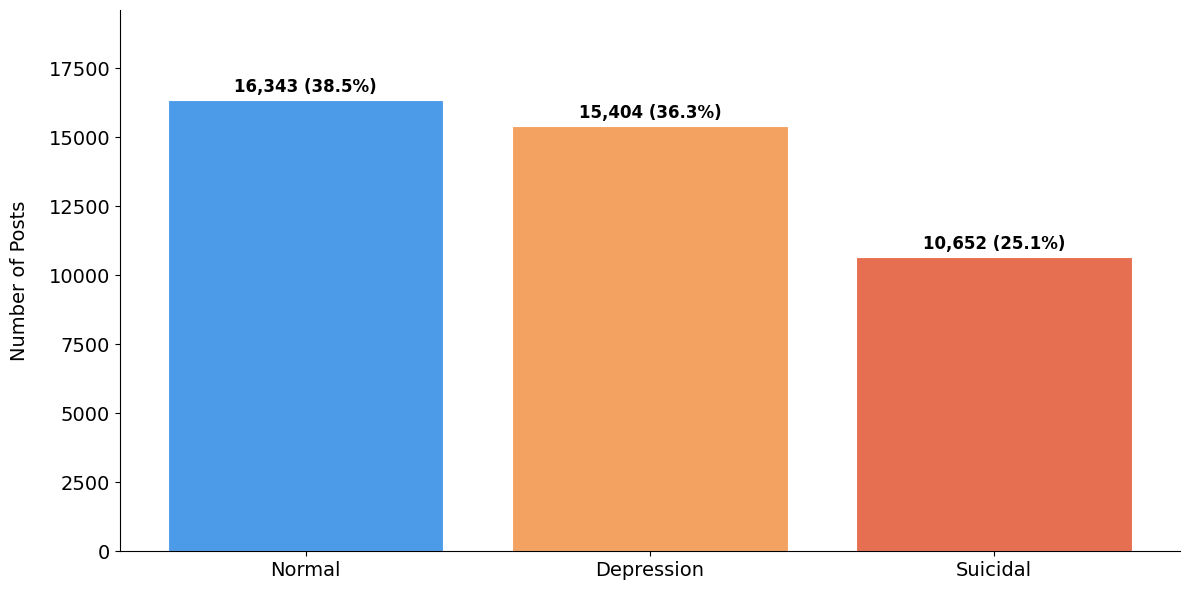

In [ ]:
# ── Figure 1 — Class Distribution ─────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

counts = [vc[l] for l in LABEL_ORDER]
total = sum(counts)
percentages = [c / total * 100 for c in counts]

bars = ax.bar(LABEL_ORDER, counts, color=PALETTE, edgecolor="white", linewidth=0.8)

#ax.set_title("Class Distribution — Raw Counts", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of Posts", fontsize=14, labelpad=14)
ax.set_ylim(0, max(counts) * 1.20)

for bar, cnt, pct in zip(bars, counts, percentages):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 150,
        f"{cnt:,} ({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis='both', labelsize=14)
plt.tight_layout()
#plt.savefig(OUT_DIR + "/fig1_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


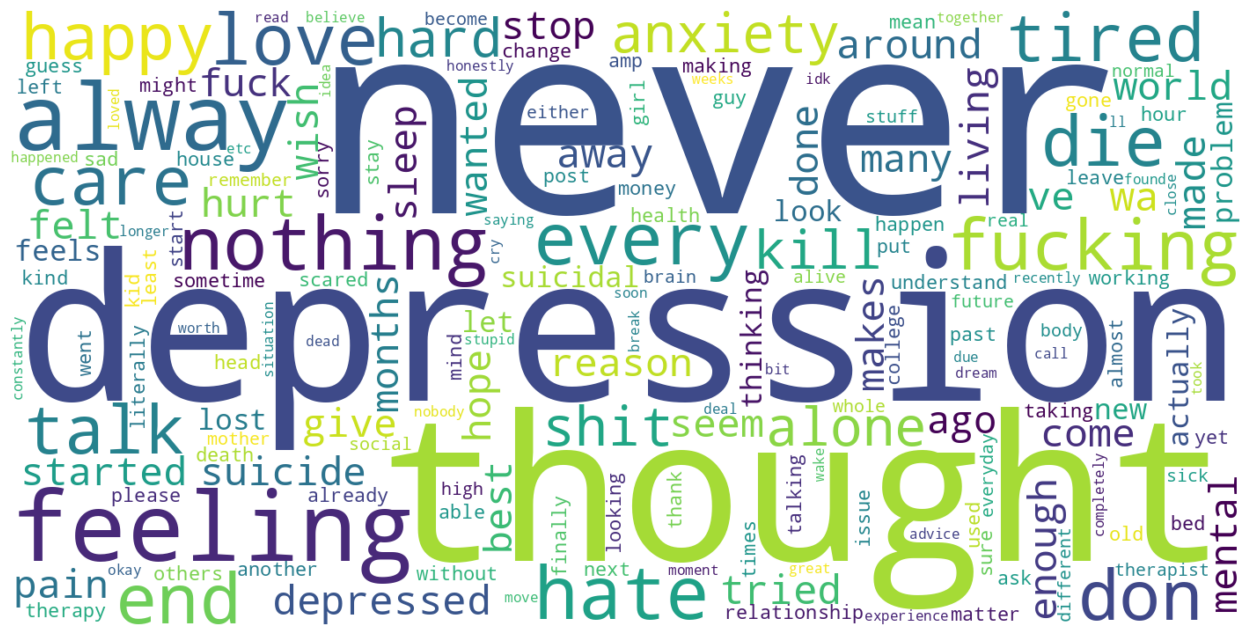

In [ ]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import re

custom_stopwords = set(STOPWORDS)

# pronouns + generic filler + broad verbs that dominate your cloud
custom_stopwords.update([
    "i", "me", "my", "mine", "myself",
    "we", "us", "our", "ours", "ourselves",
    "you", "your", "yours", "yourself", "yourselves",
    "he", "him", "his", "himself",
    "she", "her", "hers", "herself",
    "it", "its", "itself",
    "they", "them", "their", "theirs", "themselves",

    "im", "ive", "id", "ill", "dont", "didnt", "cant", "couldnt", "wasnt", "isnt",
    "would", "could", "should", "really", "much", "lot", "still", "even", "also",
    "one", "two", "thing", "things", "something", "anything", "everything", "someone", "anyone",
    "people", "person", "everyone", "anymore", "anyway",

    "know", "think", "feel", "want", "need", "make", "go", "going", "take", "got", "getting",
    "say", "said", "tell", "told", "see", "try", "trying", "find", "help", "keep",

    "day", "days", "time", "week", "month", "year", "years", "today", "now", "night", "morning",
    "back", "way", "point", "part", "place", "home", "school", "work", "job",

    "good", "bad", "better", "worse", "right", "wrong", "first", "last", "little", "long",
    "well", "too", "pretty", "maybe", "probably", "though", "tho",

    "friend", "friends", "family", "mom", "dad", "parent", "parents",
    "live", "life", "person", "self", "will", "t", "s", "m"
])

text = " ".join(df["text"].dropna().astype(str)).lower()
text = re.sub(r"http\S+|www\S+", " ", text)
text = re.sub(r"[^a-z\s]", " ", text)
text = re.sub(r"\s+", " ", text).strip()

wc = WordCloud(
    width=1400,
    height=700,
    background_color="white",
    stopwords=custom_stopwords,
    max_words=180,
    collocations=False,
    prefer_horizontal=0.85,
    min_font_size=12,
    relative_scaling=0.4
).generate(text)

plt.figure(figsize=(16, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

Posts exceeding 256 tokens : 16.1%
Posts exceeding 512 tokens : 4.8%
Recommended max_len=256 covers 83.9% of posts


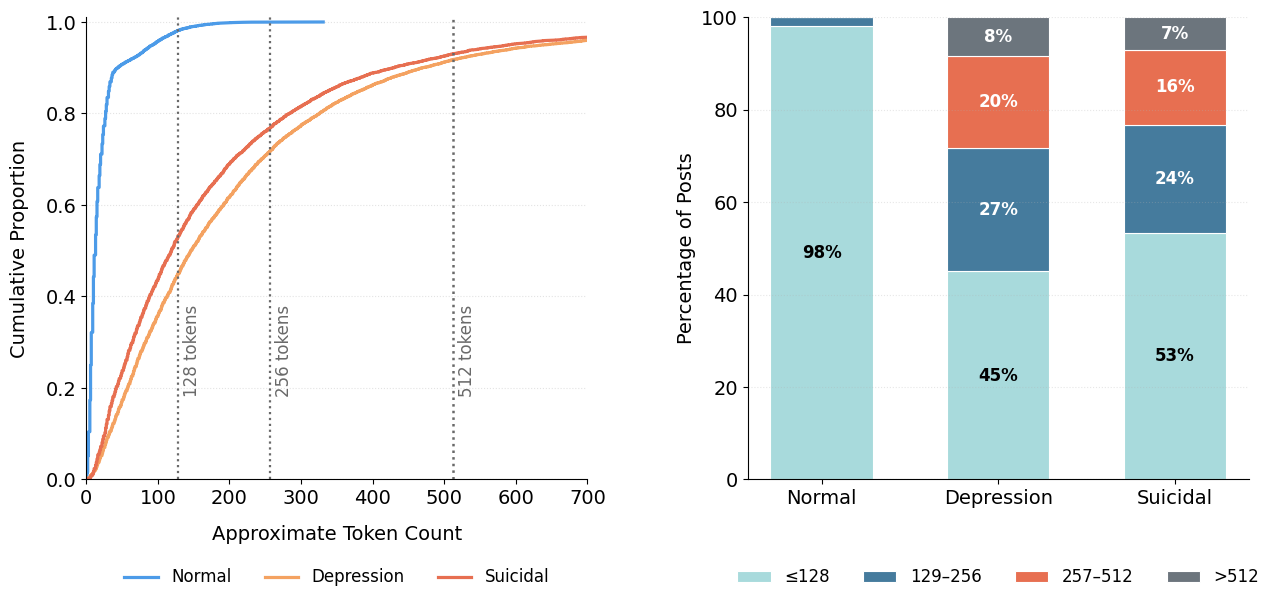

In [ ]:
# ── Figure 3 — Token Length (BERT guidance) ─────────────────────────
df["approx_tokens"] = (df["word_count"] * 1.3).astype(int)

pct_over_256 = (df["approx_tokens"] > 256).mean() * 100
pct_over_512 = (df["approx_tokens"] > 512).mean() * 100

print(f"Posts exceeding 256 tokens : {pct_over_256:.1f}%")
print(f"Posts exceeding 512 tokens : {pct_over_512:.1f}%")
print(f"Recommended max_len=256 covers {100 - pct_over_256:.1f}% of posts")

fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"wspace": 0.32})

# Panel A: ECDF of approximate token counts
ax = axes[0]

for lbl, col in zip(LABEL_ORDER, PALETTE):
    vals = np.sort(df.loc[df["label"] == lbl, "approx_tokens"].values)
    ecdf = np.arange(1, len(vals) + 1) / len(vals)
    ax.plot(vals, ecdf, lw=2.3, color=col, label=lbl)

ax.axvline(128, color="dimgray", linestyle=":", linewidth=1.6)
ax.axvline(256, color="dimgray", linestyle=":", linewidth=1.6)
ax.axvline(512, color="dimgray", linestyle=":", linewidth=1.8)

#ax.text(128 + 8, 0.28, "128 tokens", color="dimgray", fontsize=11)#teal
#ax.text(256 + 8, 0.18, "256 tokens", color="dimgray", fontsize=11) #firebrick
#ax.text(512 + 8, 0.08, "512 tokens", color="dimgray", fontsize=11)

ax.text(128+20, 0.18, "128 tokens", rotation=90,
        color="dimgray", fontsize=12, ha="center", va="bottom")

ax.text(256+20, 0.18, "256 tokens", rotation=90,
        color="dimgray", fontsize=12, ha="center", va="bottom")

ax.text(512+20, 0.18, "512 tokens", rotation=90,
        color="dimgray", fontsize=12, ha="center", va="bottom")

ax.set_xlim(0, 700)
ax.set_ylim(0, 1.01)
ax.set_xlabel("Approximate Token Count", fontsize=14, labelpad=12)
ax.set_ylabel("Cumulative Proportion", fontsize=14, labelpad=12)
#ax.set_title("Approximate Token Count ECDF", fontsize=12, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle=":", alpha=0.35)
ax.tick_params(axis='both', labelsize=14)

# Left legend
ax.legend(
    frameon=False,
    fontsize=12,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=3
)

# Panel B: 100% stacked bars for token buckets
ax = axes[1]

bins_labels = ["≤128", "129–256", "257–512", ">512"]
bin_colors  = ["#A8DADC", "#457B9D", "#E76F51", "#6C757D"]

def bin_percents(series):
    t = series.values
    return np.array([
        (t <= 128).sum(),
        ((t > 128) & (t <= 256)).sum(),
        ((t > 256) & (t <= 512)).sum(),
        (t > 512).sum()
    ]) / len(t) * 100

all_bins = np.stack([
    bin_percents(df.loc[df["label"] == l, "approx_tokens"])
    for l in LABEL_ORDER
])

x = np.arange(len(LABEL_ORDER))
bottom = np.zeros(len(LABEL_ORDER))
width = 0.58

for i, (lab, col) in enumerate(zip(bins_labels, bin_colors)):
    vals = all_bins[:, i]
    ax.bar(
        x, vals, width=width, bottom=bottom,
        color=col, edgecolor="white", linewidth=0.8, label=lab
    )

    for xi, v, btm in zip(x, vals, bottom):
        if v >= 6:
            txt_color = "white" if i >= 1 else "black"
            ax.text(
                xi, btm + v / 2, f"{v:.0f}%",
                ha="center", va="center",
                fontsize=12, fontweight="bold", color=txt_color
            )
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(LABEL_ORDER, fontsize=10)
ax.set_ylabel("Percentage of Posts", fontsize=14)
ax.set_ylim(0, 100)
#ax.set_title("Token Length Buckets by Class", fontsize=12, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle=":", alpha=0.30)
ax.tick_params(axis='both', labelsize=14)

# Right legend aligned with left legend
ax.legend(
    frameon=False,
    fontsize=12,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=4
)

plt.tight_layout(rect=[0, 0.10, 1, 0.95])
#plt.savefig(OUT_DIR + "/fig3_token.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
pct_over_128 = (df["approx_tokens"] > 128).mean() * 100
pct_over_256 = (df["approx_tokens"] > 256).mean() * 100
pct_over_512 = (df["approx_tokens"] > 512).mean() * 100

print(f"Overall: posts exceeding 128 tokens = {pct_over_128:.1f}%")
print(f"Overall: posts exceeding 256 tokens = {pct_over_256:.1f}%")
print(f"Overall: posts exceeding 512 tokens = {pct_over_512:.1f}%")
print(f"Overall: max_len=128 covers {100 - pct_over_128:.1f}% of posts")
print(f"Overall: max_len=256 covers {100 - pct_over_256:.1f}% of posts")
print()

# By class
for lbl in LABEL_ORDER:
    subset = df.loc[df["label"] == lbl, "approx_tokens"]

    pct_128 = (subset > 128).mean() * 100
    pct_256 = (subset > 256).mean() * 100
    pct_512 = (subset > 512).mean() * 100

    covered_128 = 100 - pct_128
    covered_256 = 100 - pct_256

    print(f"{lbl}: posts exceeding 128 tokens = {pct_128:.1f}%")
    print(f"{lbl}: posts exceeding 256 tokens = {pct_256:.1f}%")
    print(f"{lbl}: posts exceeding 512 tokens = {pct_512:.1f}%")
    print(f"{lbl}: max_len=128 covers {covered_128:.1f}% of posts")
    print(f"{lbl}: max_len=256 covers {covered_256:.1f}% of posts")
    print()

Overall: posts exceeding 128 tokens = 32.4%
Overall: posts exceeding 256 tokens = 16.1%
Overall: posts exceeding 512 tokens = 4.8%
Overall: max_len=128 covers 67.6% of posts
Overall: max_len=256 covers 83.9% of posts

Normal: posts exceeding 128 tokens = 1.8%
Normal: posts exceeding 256 tokens = 0.0%
Normal: posts exceeding 512 tokens = 0.0%
Normal: max_len=128 covers 98.2% of posts
Normal: max_len=256 covers 100.0% of posts

Depression: posts exceeding 128 tokens = 55.0%
Depression: posts exceeding 256 tokens = 28.3%
Depression: posts exceeding 512 tokens = 8.3%
Depression: max_len=128 covers 45.0% of posts
Depression: max_len=256 covers 71.7% of posts

Suicidal: posts exceeding 128 tokens = 46.8%
Suicidal: posts exceeding 256 tokens = 23.2%
Suicidal: posts exceeding 512 tokens = 7.0%
Suicidal: max_len=128 covers 53.2% of posts
Suicidal: max_len=256 covers 76.8% of posts



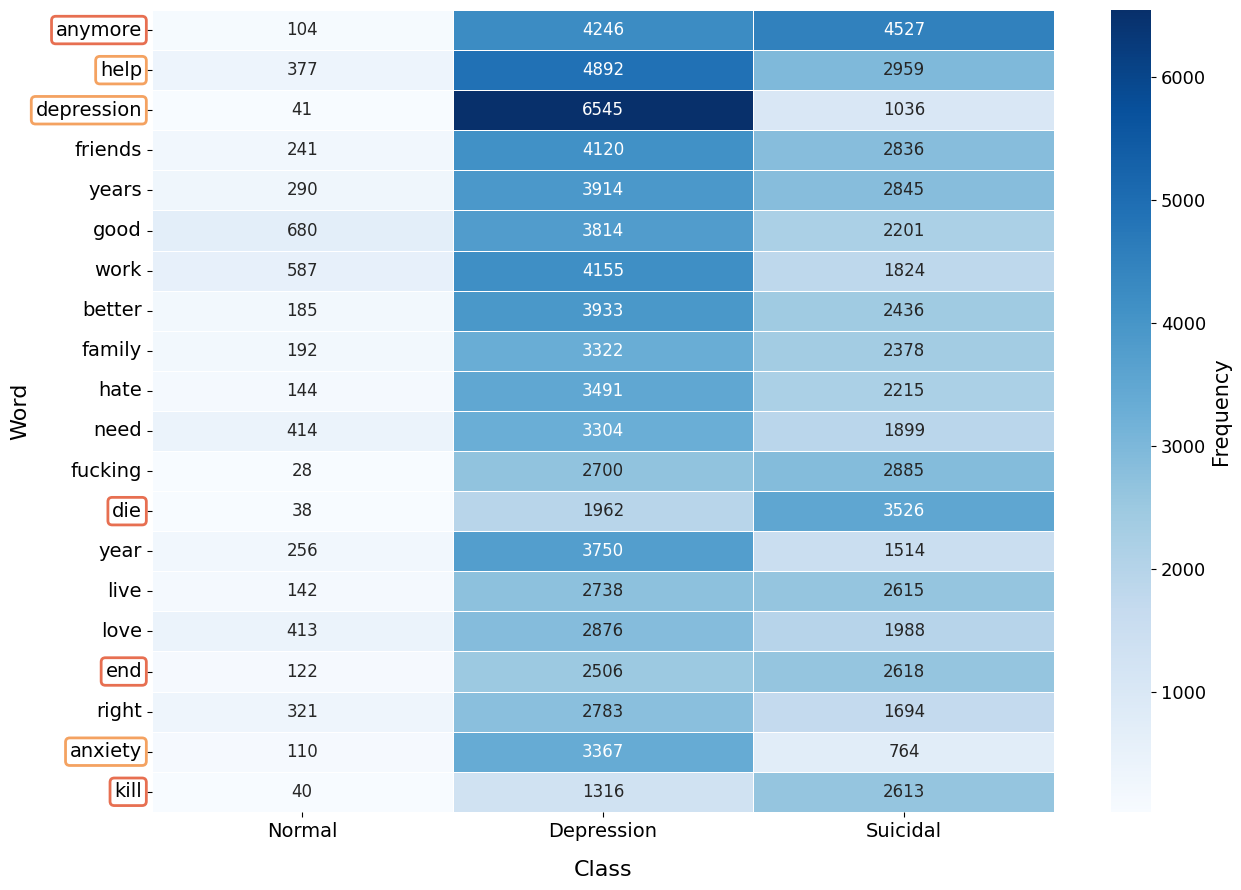

In [ ]:
# ── Top Informative Words per Class (raw-count heatmap) ──────────
from collections import Counter
import pandas as pd
import seaborn as sns
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

CUSTOM_STOPWORDS = ENGLISH_STOP_WORDS.union({
    "just", "like", "want", "really", "know", "time", "day", "today",
    "did", "don", "got", "make", "going", "think", "people", "life",
    "things", "thing", "way", "ve", "ll", "im", "doesn", "didn",
    "isn", "wasn", "aren", "weren", "can", "could", "would", "should",
    "say", "said", "feel", "feeling"
})

def quick_clean(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\d+", " ", text)
    tokens = text.split()
    return [t for t in tokens if t not in CUSTOM_STOPWORDS and len(t) > 2]

TOP_N = 12
class_counters = {}

for lbl in LABEL_ORDER:
    all_tokens = []
    for text in df.loc[df["label"] == lbl, "text"]:
        all_tokens.extend(quick_clean(text))
    class_counters[lbl] = Counter(all_tokens)

top_words_union = set()
for lbl in LABEL_ORDER:
    top_words_union.update([w for w, _ in class_counters[lbl].most_common(TOP_N)])

top_words_union = sorted(top_words_union)

mat = pd.DataFrame(index=top_words_union, columns=LABEL_ORDER).fillna(0)
for lbl in LABEL_ORDER:
    for w in top_words_union:
        mat.loc[w, lbl] = class_counters[lbl][w]

# Keep only the 20 highest-total words
mat["total"] = mat.sum(axis=1)
mat = mat.sort_values("total", ascending=False).drop(columns="total").head(20)

# Words to highlight on the y-axis
highlight_words = {
    "depression": "#F4A261",   # orange box
    "anxiety": "#F4A261",
    "help": "#F4A261",
    "die": "#E76F51",          # stronger red-orange
    "kill": "#E76F51",
    "end": "#E76F51",
    "anymore": "#E76F51"
}

fig, ax = plt.subplots(figsize=(13, 9))

hm = sns.heatmap(
    mat,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Frequency"},
    annot_kws={"fontsize": 12},
    ax=ax
)

ax.set_xlabel("Class", fontsize=16, labelpad=14)
ax.set_ylabel("Word", fontsize=16)

# Tick label sizes
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)

# Colorbar font sizes
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=13)
cbar.set_label("Frequency", fontsize=15)

# Box selected y-axis words
for tick in ax.get_yticklabels():
    word = tick.get_text()
    if word in highlight_words:
        tick.set_bbox(dict(
            facecolor="none",
            edgecolor=highlight_words[word],
            linewidth=2,
            boxstyle="round,pad=0.22"
        ))
        #tick.set_fontweight("bold")

plt.tight_layout()
#plt.savefig(OUT_DIR + "/fig4_overlap.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
'''
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13
})

fig, ax = plt.subplots(figsize=(10, 12))


#**PREPROCESSING & DATA SPLITTING**

In [ ]:
# ── Preprocessing pipelines ───────────────────────────
import time

KEEP_WORDS = {
    "i","me","my","myself","we","our","ours","ourselves",
    "no","not","nor","never","neither","nobody","nothing",
    "nowhere","cannot","cant","dont","wont","isnt","wasnt",
    "aint","shouldnt","wouldnt","couldnt","neednt","hadnt","hasnt",
}

STOPWORDS = ENGLISH_STOP_WORDS - KEEP_WORDS
_stemmer  = SnowballStemmer("english")

def preprocess_classical(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\d+", " ", text)
    tokens = text.split()
    tokens = [_stemmer.stem(t) for t in tokens if t not in STOPWORDS and len(t) > 1]
    return " ".join(tokens)

def preprocess_transformer(text):
    text = str(text).encode("ascii", "ignore").decode("ascii")
    text = re.sub(r"http\S+|www\S+", " ", text)
    return re.sub(r"\s+", " ", text).strip()

print("Applying classical ML pipeline …")
t0 = time.time()
df["text_clean"] = df["text"].apply(preprocess_classical)
print(f"  Done in {time.time()-t0:.1f}s")

print("Applying transformer pipeline …")
t0 = time.time()
df["text_transformer"] = df["text"].apply(preprocess_transformer)
print(f"  Done in {time.time()-t0:.1f}s")


import numpy as np

np.random.seed(42)  # global seed (optional but good practice)

# Sanity check
for lbl in LABEL_ORDER:
    row = df[df["label"] == lbl].sample(n=1, random_state=42).iloc[0]

    print(f"\n[{lbl}]")
    print(f"  Original    : {row['text'][:100]}")
    print(f"  Classical   : {row['text_clean'][:100]}")
    print(f"  Transformer : {row['text_transformer'][:100]}")


Applying classical ML pipeline …
  Done in 15.7s
Applying transformer pipeline …
  Done in 1.7s

[Normal]
  Original    : spring is finally here cherry blossom galore such a shame they are so temporary
  Classical   : spring final cherri blossom galor shame temporari
  Transformer : spring is finally here cherry blossom galore such a shame they are so temporary

[Depression]
  Original    : I try so hard to be happy. For me, for my family for my friends. But I cannot. I am jealous of my fr
  Classical   : tri hard happi me my famili my friend cannot jealous my friend happi live happi cannot tell suffer i
  Transformer : I try so hard to be happy. For me, for my family for my friends. But I cannot. I am jealous of my fr

[Suicidal]
  Original    : The only reason I do not is because i feel so bad about how my brother will be all alone and my fath
  Classical   : reason not feel bad my brother my father depress wish explain realli want peac mind death way want e
  Transformer : The only 

In [ ]:
# ── Train / Val / Test split & save ───────────────────
X_clean = df["text_clean"].values
X_raw   = df["text_transformer"].values
y       = df["label"].values

X_c_tv, X_c_test, X_r_tv, X_r_test, y_tv, y_test = train_test_split(
    X_clean, X_raw, y, test_size=0.15, stratify=y, random_state=42
)

X_c_train, X_c_val, X_r_train, X_r_val, y_train, y_val = train_test_split(
    X_c_tv, X_r_tv, y_tv, test_size=0.1765, stratify=y_tv, random_state=42)

print(f"Train : {len(y_train):,} | Val : {len(y_val):,} | Test : {len(y_test):,}")
for split_name, y_split in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    counts = {l: (y_split==l).sum() for l in LABEL_ORDER}
    print(f"  {split_name}: " + "  |  ".join(
        f"{l} {counts[l]:,} ({counts[l]/len(y_split)*100:.1f}%)" for l in LABEL_ORDER))

splits = {"X_train": X_c_train, "X_val": X_c_val, "X_test": X_c_test,
          "X_train_raw": X_r_train, "X_val_raw": X_r_val, "X_test_raw": X_r_test,
          "y_train": y_train, "y_val": y_val, "y_test": y_test}

for name, arr in splits.items():
    np.save(f"{SPLITS_DIR}/{name}.npy", arr)

Train : 29,678 | Val : 6,361 | Test : 6,360
  Train: Normal 11,440 (38.5%)  |  Depression 10,782 (36.3%)  |  Suicidal 7,456 (25.1%)
  Val: Normal 2,452 (38.5%)  |  Depression 2,311 (36.3%)  |  Suicidal 1,598 (25.1%)
  Test: Normal 2,451 (38.5%)  |  Depression 2,311 (36.3%)  |  Suicidal 1,598 (25.1%)


#**BASELINE MODELS**
During the first run, the dataset is split and saved to disk.
If these saved splits are available, you can skip the preprocessing
steps above and proceed directly from this section.

##**VADER & CLASSICAL ML MODELS**

In [1]:
import re, os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)

try:
    from vader_sentiment.vader_sentiment import SentimentIntensityAnalyzer
except ImportError:
    !pip install vader-sentiment -q
    from vader_sentiment.vader_sentiment import SentimentIntensityAnalyzer


import random
import numpy as np
import torch
import os

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

warnings.filterwarnings("ignore")

LABEL_ORDER = ["Normal", "Depression", "Suicidal"]
COLORS      = {"Normal": "#4C9BE8", "Depression": "#F4A261", "Suicidal": "#E76F51"}
PALETTE     = [COLORS[l] for l in LABEL_ORDER]

OUT_DIR    = "/content/drive/MyDrive/BIOS735/Final/outputs"
SPLITS_DIR = OUT_DIR + "/splits"

# ── Load splits ───────────────────────────────────────
X_train     = np.load(f"{SPLITS_DIR}/X_train.npy",     allow_pickle=True)
X_val       = np.load(f"{SPLITS_DIR}/X_val.npy",       allow_pickle=True)
X_test      = np.load(f"{SPLITS_DIR}/X_test.npy",      allow_pickle=True)
X_train_raw = np.load(f"{SPLITS_DIR}/X_train_raw.npy", allow_pickle=True)
X_val_raw   = np.load(f"{SPLITS_DIR}/X_val_raw.npy",   allow_pickle=True)
X_test_raw  = np.load(f"{SPLITS_DIR}/X_test_raw.npy",  allow_pickle=True)
y_train     = np.load(f"{SPLITS_DIR}/y_train.npy",     allow_pickle=True)
y_val       = np.load(f"{SPLITS_DIR}/y_val.npy",       allow_pickle=True)
y_test      = np.load(f"{SPLITS_DIR}/y_test.npy",      allow_pickle=True)

print(f"Train: {len(y_train):,}  Val: {len(y_val):,}  Test: {len(y_test):,}")

# ── Evaluation helper ─────────────────────────────────
ALL_RESULTS  = {}
ALL_CMS      = {}
EFFICIENCY   = {}

def evaluate(name, y_true, y_pred, train_time=None, infer_time=None):
    rep = classification_report(y_true, y_pred,
                                target_names=LABEL_ORDER, output_dict=True)
    print(f"\n{'─'*55}")
    print(f"  {name}")
    print(f"{'─'*55}")
    print(classification_report(y_true, y_pred,
                                target_names=LABEL_ORDER, digits=3))
    if train_time is not None:
        print(f"  Train time  : {train_time:.1f}s")
    if infer_time is not None:
        print(f"  Infer time  : {infer_time:.3f}s  "
              f"({len(y_true)/infer_time:.0f} posts/sec)")

    ALL_RESULTS[name] = {
        "acc":      accuracy_score(y_true, y_pred),
        "macro_f1": rep["macro avg"]["f1-score"],
        **{f"{c}_f1": rep[c]["f1-score"]  for c in LABEL_ORDER},
        **{f"{c}_p":  rep[c]["precision"] for c in LABEL_ORDER},
        **{f"{c}_r":  rep[c]["recall"]    for c in LABEL_ORDER},
    }
    ALL_CMS[name] = confusion_matrix(y_true, y_pred, labels=LABEL_ORDER)
    if train_time is not None or infer_time is not None:
        EFFICIENCY[name] = {
            "train_time": train_time,
            "infer_time": infer_time,
            "throughput": len(y_true) / infer_time if infer_time else None,
        }


# ── Model 1: VADER ────────────────────────────────────
print("=" * 55)
print("  Model 1: VADER Sentiment Baseline")
print("=" * 55)

sia = SentimentIntensityAnalyzer()
best_f1, best_t = -1, (-0.60, -0.15)
for t_sui in [-0.75, -0.65, -0.55, -0.45]:
    for t_dep in [-0.25, -0.15, -0.05]:
        preds_v = []
        for text in X_val_raw:
            s = sia.polarity_scores(str(text))
            if s["compound"] <= t_sui and s["neg"] >= 0.25:
                preds_v.append("Suicidal")
            elif s["compound"] <= t_dep:
                preds_v.append("Depression")
            else:
                preds_v.append("Normal")
        f1 = f1_score(y_val, preds_v, average="macro")
        if f1 > best_f1:
            best_f1, best_t = f1, (t_sui, t_dep)

t_sui, t_dep = best_t
print(f"Best thresholds: suicidal ≤ {t_sui}, depression ≤ {t_dep}")

t0 = time.time()
preds_vader = []
for text in X_test_raw:
    s = sia.polarity_scores(str(text))
    if s["compound"] <= t_sui and s["neg"] >= 0.25:
        preds_vader.append("Suicidal")
    elif s["compound"] <= t_dep:
        preds_vader.append("Depression")
    else:
        preds_vader.append("Normal")
infer_time = time.time() - t0
preds_vader = np.array(preds_vader)
evaluate("VADER", y_test, preds_vader, train_time=0.0, infer_time=infer_time)


# ── Model 2: LR (BoW) ─────────────────────────────────
print("=" * 55)
print("  Model 2: Logistic Regression — Bag-of-Words")
print("=" * 55)

pipe_lr_bow = Pipeline([
    ("vec", CountVectorizer(max_features=50000, ngram_range=(1, 2),
                            min_df=2, max_df=0.95)),
    ("clf", LogisticRegression(max_iter=1000, C=1.0, class_weight="balanced",
                               solver="saga", n_jobs=-1, random_state=42)),
])
t0 = time.time()
pipe_lr_bow.fit(X_train, y_train)
train_time = time.time() - t0

t0 = time.time()
preds = pipe_lr_bow.predict(X_test)
infer_time = time.time() - t0
evaluate("LR (BoW)", y_test, preds, train_time=train_time, infer_time=infer_time)


# ── Model 3: LR (TF-IDF) ──────────────────────────────
print("=" * 55)
print("  Model 3: Logistic Regression — TF-IDF")
print("=" * 55)

pipe_lr_tfidf = Pipeline([
    ("vec", TfidfVectorizer(max_features=50000, ngram_range=(1, 2),
                             min_df=2, max_df=0.95, sublinear_tf=True)),
    ("clf", LogisticRegression(max_iter=1000, C=1.0, class_weight="balanced",
                               solver="saga", n_jobs=-1, random_state=42)),
])
t0 = time.time()
pipe_lr_tfidf.fit(X_train, y_train)
train_time = time.time() - t0

t0 = time.time()
preds = pipe_lr_tfidf.predict(X_test)
infer_time = time.time() - t0
evaluate("LR (TF-IDF)", y_test, preds, train_time=train_time, infer_time=infer_time)


# ── Model 4: SVM (TF-IDF) ─────────────────────────────
print("=" * 55)
print("  Model 4: Linear SVM — TF-IDF")
print("=" * 55)

pipe_svm = Pipeline([
    ("vec", TfidfVectorizer(max_features=50000, ngram_range=(1, 2),
                             min_df=2, max_df=0.95, sublinear_tf=True)),
    ("clf", LinearSVC(C=0.5, max_iter=2000, class_weight="balanced",
                      random_state=42)),
])
t0 = time.time()
pipe_svm.fit(X_train, y_train)
train_time = time.time() - t0

t0 = time.time()
preds = pipe_svm.predict(X_test)
infer_time = time.time() - t0
evaluate("LinearSVM (TF-IDF)", y_test, preds, train_time=train_time, infer_time=infer_time)


# ── Model 5: Naive Bayes (TF-IDF) ─────────────────────
print("=" * 55)
print("  Model 5: Multinomial Naive Bayes — TF-IDF")
print("=" * 55)

pipe_nb = Pipeline([
    ("vec", TfidfVectorizer(max_features=50000, ngram_range=(1, 2),
                             min_df=2, max_df=0.95)),
    ("clf", MultinomialNB(alpha=0.1)),
])
t0 = time.time()
pipe_nb.fit(X_train, y_train)
train_time = time.time() - t0

t0 = time.time()
preds = pipe_nb.predict(X_test)
infer_time = time.time() - t0
evaluate("Naive Bayes (TF-IDF)", y_test, preds, train_time=train_time, infer_time=infer_time)


# ── Model 6: LSA + LR ─────────────────────────────────
print("=" * 55)
print("  Model 6: Dense Embeddings (LSA 300d) + LR")
print("=" * 55)

pipe_lsa = Pipeline([
    ("vec",  TfidfVectorizer(max_features=50000, ngram_range=(1, 2),
                              min_df=2, max_df=0.95, sublinear_tf=True)),
    ("svd",  TruncatedSVD(n_components=300, random_state=42)),
    ("norm", Normalizer(copy=False)),
    ("clf",  LogisticRegression(max_iter=1000, C=1.0, class_weight="balanced",
                                solver="saga", random_state=42)),
])
t0 = time.time()
pipe_lsa.fit(X_train, y_train)
train_time = time.time() - t0

t0 = time.time()
preds = pipe_lsa.predict(X_test)
infer_time = time.time() - t0
evaluate("Embeddings+LR (LSA)", y_test, preds, train_time=train_time, infer_time=infer_time)


# ── Model 7: Decision Tree (TF-IDF) ───────────────────
print("=" * 55)
print("  Model 7: Decision Tree — TF-IDF")
print("=" * 55)

pipe_dt = Pipeline([
    ("vec", TfidfVectorizer(max_features=30000, ngram_range=(1, 2),
                             min_df=2, max_df=0.95, sublinear_tf=True)),
    ("clf", DecisionTreeClassifier(max_depth=50, class_weight="balanced",
                                    random_state=42)),
])
t0 = time.time()
pipe_dt.fit(X_train, y_train)
train_time = time.time() - t0

t0 = time.time()
preds = pipe_dt.predict(X_test)
infer_time = time.time() - t0
evaluate("Decision Tree (TF-IDF)", y_test, preds, train_time=train_time, infer_time=infer_time)


# ── Model 8: Random Forest (TF-IDF) ───────────────────
print("=" * 55)
print("  Model 8: Random Forest — TF-IDF")
print("=" * 55)

pipe_rf = Pipeline([
    ("vec", TfidfVectorizer(max_features=30000, ngram_range=(1, 2),
                             min_df=2, max_df=0.95, sublinear_tf=True)),
    ("clf", RandomForestClassifier(n_estimators=200, max_depth=50,
                                    max_features="sqrt",
                                    class_weight="balanced",
                                    n_jobs=-1, random_state=42)),
])
t0 = time.time()
pipe_rf.fit(X_train, y_train)
train_time = time.time() - t0

t0 = time.time()
preds = pipe_rf.predict(X_test)
infer_time = time.time() - t0
evaluate("Random Forest (TF-IDF)", y_test, preds, train_time=train_time, infer_time=infer_time)


# ── Efficiency Summary ────────────────────────────────
print("\n" + "=" * 65)
print("  Efficiency Summary")
print("=" * 65)
print(f"{'Model':<25} {'Train (s)':>10} {'Infer (s)':>10} {'Posts/sec':>12}")
print("-" * 65)
for name, times in EFFICIENCY.items():
    train_str = f"{times['train_time']:.1f}" if times['train_time'] is not None else "---"
    infer_str = f"{times['infer_time']:.3f}" if times['infer_time'] is not None else "---"
    through_str = f"{times['throughput']:.0f}" if times['throughput'] is not None else "---"
    print(f"{name:<25} {train_str:>10} {infer_str:>10} {through_str:>12}")

Train: 29,678  Val: 6,361  Test: 6,360
  Model 1: VADER Sentiment Baseline
Best thresholds: suicidal ≤ -0.45, depression ≤ -0.25

───────────────────────────────────────────────────────
  VADER
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

      Normal      0.508     0.456     0.481      2311
  Depression      0.598     0.794     0.682      2451
    Suicidal      0.383     0.247     0.300      1598

    accuracy                          0.534      6360
   macro avg      0.496     0.499     0.488      6360
weighted avg      0.511     0.534     0.513      6360

  Train time  : 0.0s
  Infer time  : 15.514s  (410 posts/sec)
  Model 2: Logistic Regression — Bag-of-Words

───────────────────────────────────────────────────────
  LR (BoW)
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

      Normal      0.797     0.715     0.754      2311
  Depression      0.924     

In [15]:
# ── Classical ML Full Results Table ──────────────────
CLASSICAL_ORDER = [
    "VADER",
    "LR (BoW)",
    "LR (TF-IDF)",
    "LinearSVM (TF-IDF)",
    "Naive Bayes (TF-IDF)",
    "Decision Tree (TF-IDF)",
    "Random Forest (TF-IDF)",
    "Embeddings+LR (LSA)",
]

CLASSICAL_LABELS = [
    "VADER",
    "LR (BoW)",
    "LR (TF-IDF)",
    "SVM (TF-IDF)",
    "NB (TF-IDF)",
    "DT (TF-IDF)",
    "RF (TF-IDF)",
    "LSA+LR",
]

rows = []
for key, label in zip(CLASSICAL_ORDER, CLASSICAL_LABELS):
    if key not in ALL_RESULTS:
        continue
    r = ALL_RESULTS[key]
    e = EFFICIENCY.get(key, {})

    train_t  = e.get("train_time")
    infer_t  = e.get("infer_time")
    through  = e.get("throughput")

    rows.append({
        "Model":          label,
        "Accuracy":       round(r["acc"],           3),
        "Macro F1":       round(r["macro_f1"],      3),
        "Normal F1":      round(r["Normal_f1"],     3),
        "Depression F1":  round(r["Depression_f1"], 3),
        "Suicidal F1":    round(r["Suicidal_f1"],   3),
        "Train Time (s)": f"{train_t:.1f}" if train_t is not None else "---",
        "Inference (s)":  f"{infer_t:.3f}" if infer_t is not None else "---",
        "Posts/sec":      f"{through:.0f}" if through is not None else "---",
    })

df_classical = pd.DataFrame(rows)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
print("\n" + "=" * 65)
print("  Classical ML Results + Efficiency")
print("=" * 65)
print(df_classical.to_string(index=False))

out_path = f"{OUT_DIR}/classical_results_summary.csv"
df_classical.to_csv(out_path, index=False)
#print(f"\nSaved: {out_path}")


  Classical ML Results + Efficiency
       Model  Accuracy  Macro F1  Normal F1  Depression F1  Suicidal F1 Train Time (s) Inference (s) Posts/sec
       VADER     0.534     0.488      0.481          0.682        0.300            0.0        15.514       410
    LR (BoW)     0.804     0.793      0.754          0.918        0.709          114.4         0.584     10888
 LR (TF-IDF)     0.813     0.799      0.759          0.930        0.710            9.8         0.553     11500
SVM (TF-IDF)     0.807     0.790      0.755          0.929        0.685            7.1         0.986      6453
 NB (TF-IDF)     0.762     0.752      0.723          0.874        0.659            5.7         0.581     10955
 DT (TF-IDF)     0.744     0.724      0.688          0.896        0.586           35.5         0.549     11586
 RF (TF-IDF)     0.769     0.744      0.727          0.884        0.620          137.7         1.061      5996
      LSA+LR     0.816     0.804      0.759          0.935        0.717    

##**ZERO-SHOT LLM**
Need to restart runtime and change to GPU to speed up computations.

In [ ]:
# Quick reload after runtime reset — run this instead of Cells 1-8
import numpy as np, os, warnings, time
warnings.filterwarnings("ignore")
np.random.seed(42)

LABEL_ORDER = ["Normal", "Depression", "Suicidal"]
COLORS      = {"Normal": "#4C9BE8", "Depression": "#F4A261", "Suicidal": "#E76F51"}
OUT_DIR     = "/content/drive/MyDrive/BIOS735/Final/outputs"
SPLITS_DIR  = OUT_DIR + "/splits"

X_train     = np.load(f"{SPLITS_DIR}/X_train.npy",     allow_pickle=True)
X_val       = np.load(f"{SPLITS_DIR}/X_val.npy",       allow_pickle=True)
X_test      = np.load(f"{SPLITS_DIR}/X_test.npy",      allow_pickle=True)
X_train_raw = np.load(f"{SPLITS_DIR}/X_train_raw.npy", allow_pickle=True)
X_val_raw   = np.load(f"{SPLITS_DIR}/X_val_raw.npy",   allow_pickle=True)
X_test_raw  = np.load(f"{SPLITS_DIR}/X_test_raw.npy",  allow_pickle=True)
y_train     = np.load(f"{SPLITS_DIR}/y_train.npy",     allow_pickle=True)
y_val       = np.load(f"{SPLITS_DIR}/y_val.npy",       allow_pickle=True)
y_test      = np.load(f"{SPLITS_DIR}/y_test.npy",      allow_pickle=True)

print(f"Splits loaded ✓  |  Train: {len(y_train):,}  Val: {len(y_val):,}  Test: {len(y_test):,}")

Splits loaded ✓  |  Train: 29,678  Val: 6,361  Test: 6,360


In [ ]:
# ── Zero-Shot LLM Baseline (BART, full test set, GPU) ─
from transformers import pipeline
from torch.utils.data import Dataset
import torch
import numpy as np
import time

class TextDataset(Dataset):
    def __init__(self, texts):
        self.texts = [str(t)[:512] for t in texts]
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        return self.texts[idx]

print("Loading model …")
classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=0,
)
print(f"Model loaded ✓  |  GPU: {torch.cuda.get_device_name(0)}\n")

CANDIDATE_LABELS = [
    "normal everyday content",
    "depression and sadness",
    "suicidal thoughts and self-harm",
]
LABEL_MAP = {
    "normal everyday content":         "Normal",
    "depression and sadness":          "Depression",
    "suicidal thoughts and self-harm": "Suicidal",
}

dataset = TextDataset(X_test_raw)
total   = len(dataset)
print(f"Classifying {total:,} posts …\n")

all_preds = []
t0 = time.time()

for i, result in enumerate(classifier(dataset, CANDIDATE_LABELS,
                                       multi_label=False, batch_size=64)):
    all_preds.append(LABEL_MAP[result["labels"][0]])

    if (i + 1) % 64 == 0 or (i + 1) == total:
        done    = i + 1
        elapsed = time.time() - t0
        eta     = (elapsed / done) * (total - done)
        pct     = done / total * 100
        bar     = "█" * int(pct // 5) + "░" * (20 - int(pct // 5))
        print(f"  [{bar}] {done:,}/{total:,}  {pct:.0f}%  "
              f"elapsed {elapsed:.0f}s  ETA {eta:.0f}s")

elapsed = time.time() - t0
print(f"\nDone — {elapsed:.1f}s  ({total/elapsed:.0f} posts/sec)")

preds_llm = np.array(all_preds)
evaluate("Zero-Shot LLM", y_test, preds_llm)

Loading model …


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Model loaded ✓  |  GPU: Tesla T4

Classifying 6,360 posts …

  [░░░░░░░░░░░░░░░░░░░░] 64/6,360  1%  elapsed 5s  ETA 512s
  [░░░░░░░░░░░░░░░░░░░░] 128/6,360  2%  elapsed 10s  ETA 511s
  [░░░░░░░░░░░░░░░░░░░░] 192/6,360  3%  elapsed 16s  ETA 505s
  [░░░░░░░░░░░░░░░░░░░░] 256/6,360  4%  elapsed 21s  ETA 503s
  [█░░░░░░░░░░░░░░░░░░░] 320/6,360  5%  elapsed 27s  ETA 501s
  [█░░░░░░░░░░░░░░░░░░░] 384/6,360  6%  elapsed 32s  ETA 495s
  [█░░░░░░░░░░░░░░░░░░░] 448/6,360  7%  elapsed 37s  ETA 492s
  [█░░░░░░░░░░░░░░░░░░░] 512/6,360  8%  elapsed 43s  ETA 485s
  [█░░░░░░░░░░░░░░░░░░░] 576/6,360  9%  elapsed 48s  ETA 481s
  [██░░░░░░░░░░░░░░░░░░] 640/6,360  10%  elapsed 53s  ETA 473s
  [██░░░░░░░░░░░░░░░░░░] 704/6,360  11%  elapsed 58s  ETA 468s
  [██░░░░░░░░░░░░░░░░░░] 768/6,360  12%  elapsed 64s  ETA 464s
  [██░░░░░░░░░░░░░░░░░░] 832/6,360  13%  elapsed 69s  ETA 458s
  [██░░░░░░░░░░░░░░░░░░] 896/6,360  14%  elapsed 74s  ETA 453s
  [███░░░░░░░░░░░░░░░░░] 960/6,360  15%  elapsed 79s  ETA 447s
  [██

##**MODEL COMPARISONS**

In [5]:
# ── Save all model predictions ─────────────────────────────────
import numpy as np

SPLITS_DIR = "/content/drive/MyDrive/BIOS735/Final/outputs/splits"

preds_to_save = {
    "preds_vader":    preds_vader,
    "preds_lr_bow":   pipe_lr_bow.predict(X_test),
    "preds_lr_tfidf": pipe_lr_tfidf.predict(X_test),
    "preds_svm":      pipe_svm.predict(X_test),
    "preds_nb":       pipe_nb.predict(X_test),
    "preds_dt":       pipe_dt.predict(X_test),
    "preds_rf":       pipe_rf.predict(X_test),
    "preds_lsa":      pipe_lsa.predict(X_test),
    "preds_llm":      preds_llm,
}

for name, arr in preds_to_save.items():
    np.save(f"{SPLITS_DIR}/{name}.npy", arr)


───────────────────────────────────────────────────────
  Zero-Shot LLM
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

      Normal      0.440     0.841     0.578      2311
  Depression      0.849     0.309     0.453      2451
    Suicidal      0.597     0.394     0.475      1598

    accuracy                          0.524      6360
   macro avg      0.629     0.515     0.502      6360
weighted avg      0.637     0.524     0.504      6360



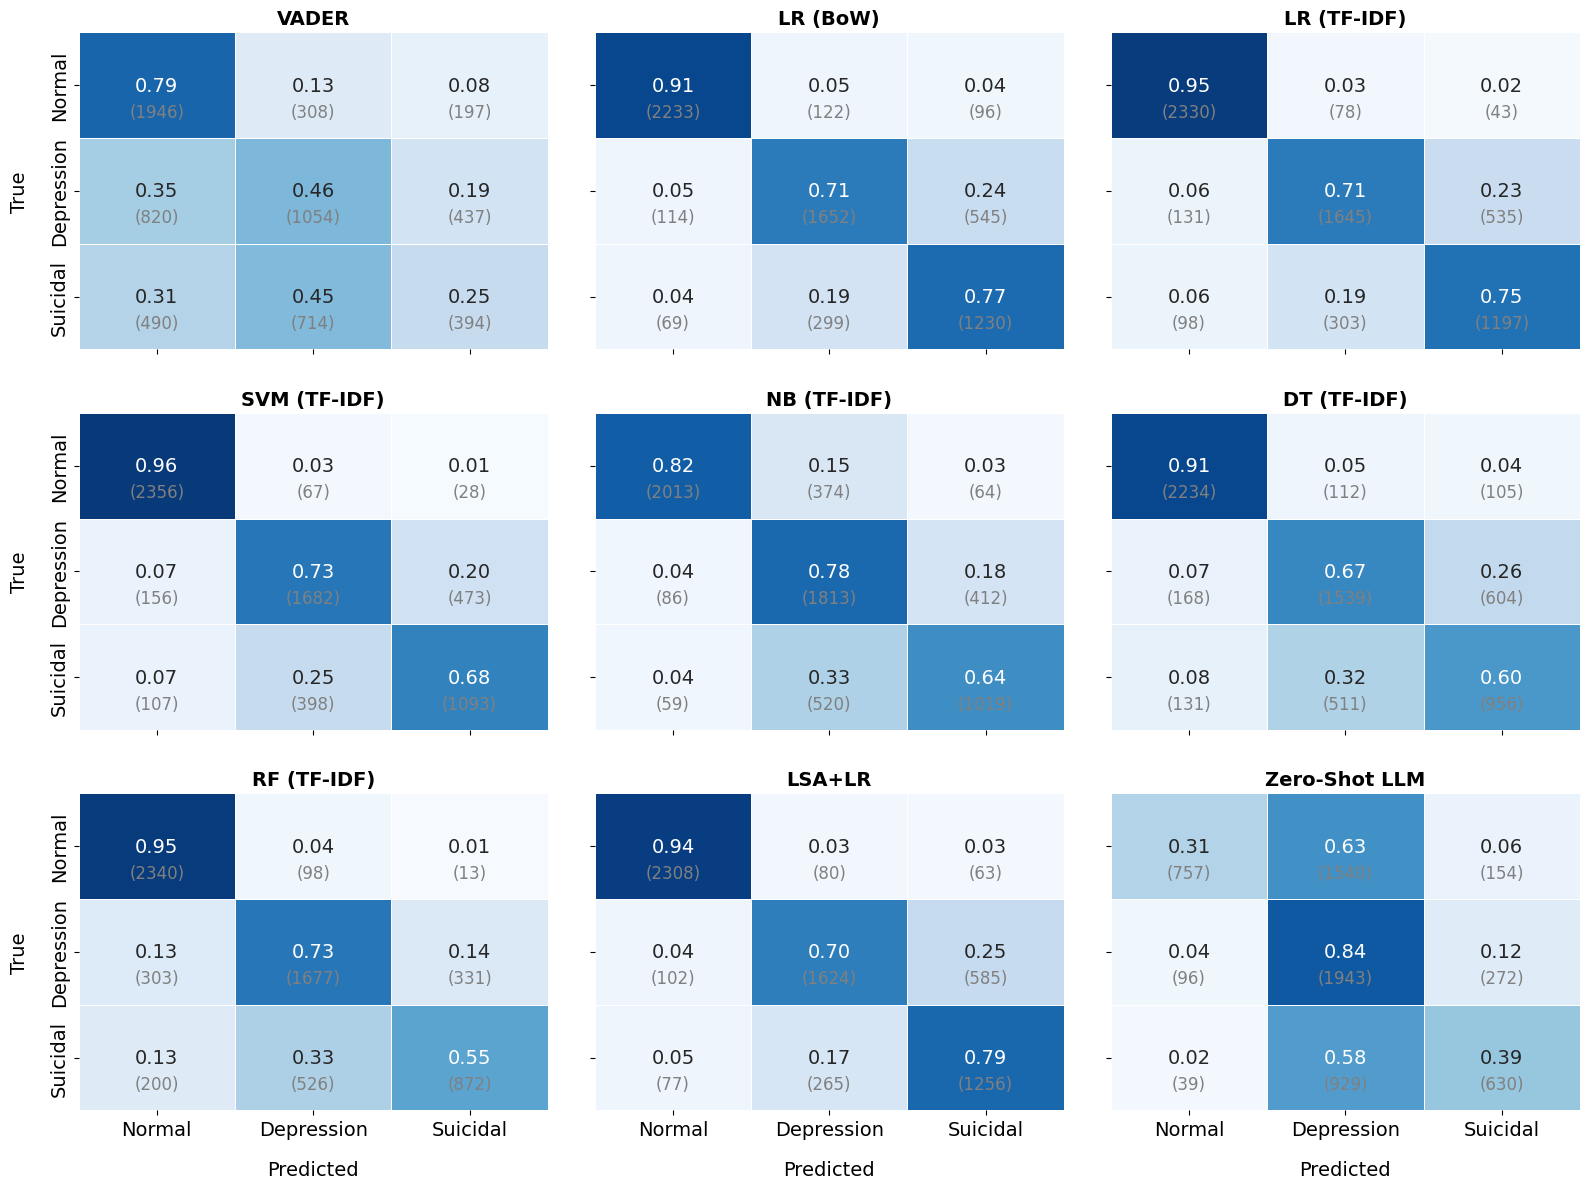

In [12]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

evaluate("Zero-Shot LLM", y_test, preds_llm)

MODEL_ORDER  = [
    "VADER",
    "LR (BoW)",
    "LR (TF-IDF)",
    "LinearSVM (TF-IDF)",
    "Naive Bayes (TF-IDF)",
    "Decision Tree (TF-IDF)",
    "Random Forest (TF-IDF)",
    "Embeddings+LR (LSA)",
    "Zero-Shot LLM",
]

MODEL_LABELS = [
    "VADER",
    "LR (BoW)",
    "LR (TF-IDF)",
    "SVM (TF-IDF)",
    "NB (TF-IDF)",
    "DT (TF-IDF)",
    "RF (TF-IDF)",
    "LSA+LR",
    "Zero-Shot LLM",
]

def plot_cm(cm, name, ax, show_xlabel=False, show_ylabel=False):
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm  = np.where(row_sums > 0, cm.astype(float) / row_sums, 0)

    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=LABEL_ORDER,
        yticklabels=LABEL_ORDER,
        ax=ax,
        cbar=False,
        linewidths=0.5,
        vmin=0,
        vmax=1,
        annot_kws={"size": 14}
    )

    for i in range(3):
        for j in range(3):
            ax.text(
                j + 0.5, i + 0.75, f"({cm[i,j]})",
                ha="center", va="center", fontsize=12, color="gray"
            )

    ax.set_title(name, fontsize=14, fontweight="bold")

    if show_xlabel:
        ax.set_xlabel("Predicted", fontsize=14, labelpad=15)
    else:
        ax.set_xlabel("")

    if show_ylabel:
        ax.set_ylabel("True", fontsize=14, labelpad=15)
    else:
        ax.set_ylabel("")

    if not show_xlabel:
      ax.set_xticklabels([])

    if not show_ylabel:
      ax.set_yticklabels([])

    ax.tick_params(labelsize=14)

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes_flat = axes.flatten()

for i, (k, lbl) in enumerate(zip(MODEL_ORDER, MODEL_LABELS)):
    row = i // 3
    col = i % 3

    plot_cm(
        ALL_CMS[k],
        lbl,
        axes_flat[i],
        show_xlabel=(row == 2),   # only bottom row
        show_ylabel=(col == 0)    # only left column
    )

for j in range(len(MODEL_ORDER), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(wspace=0.1, hspace=0.2)
plt.savefig(OUT_DIR + "/fig5_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

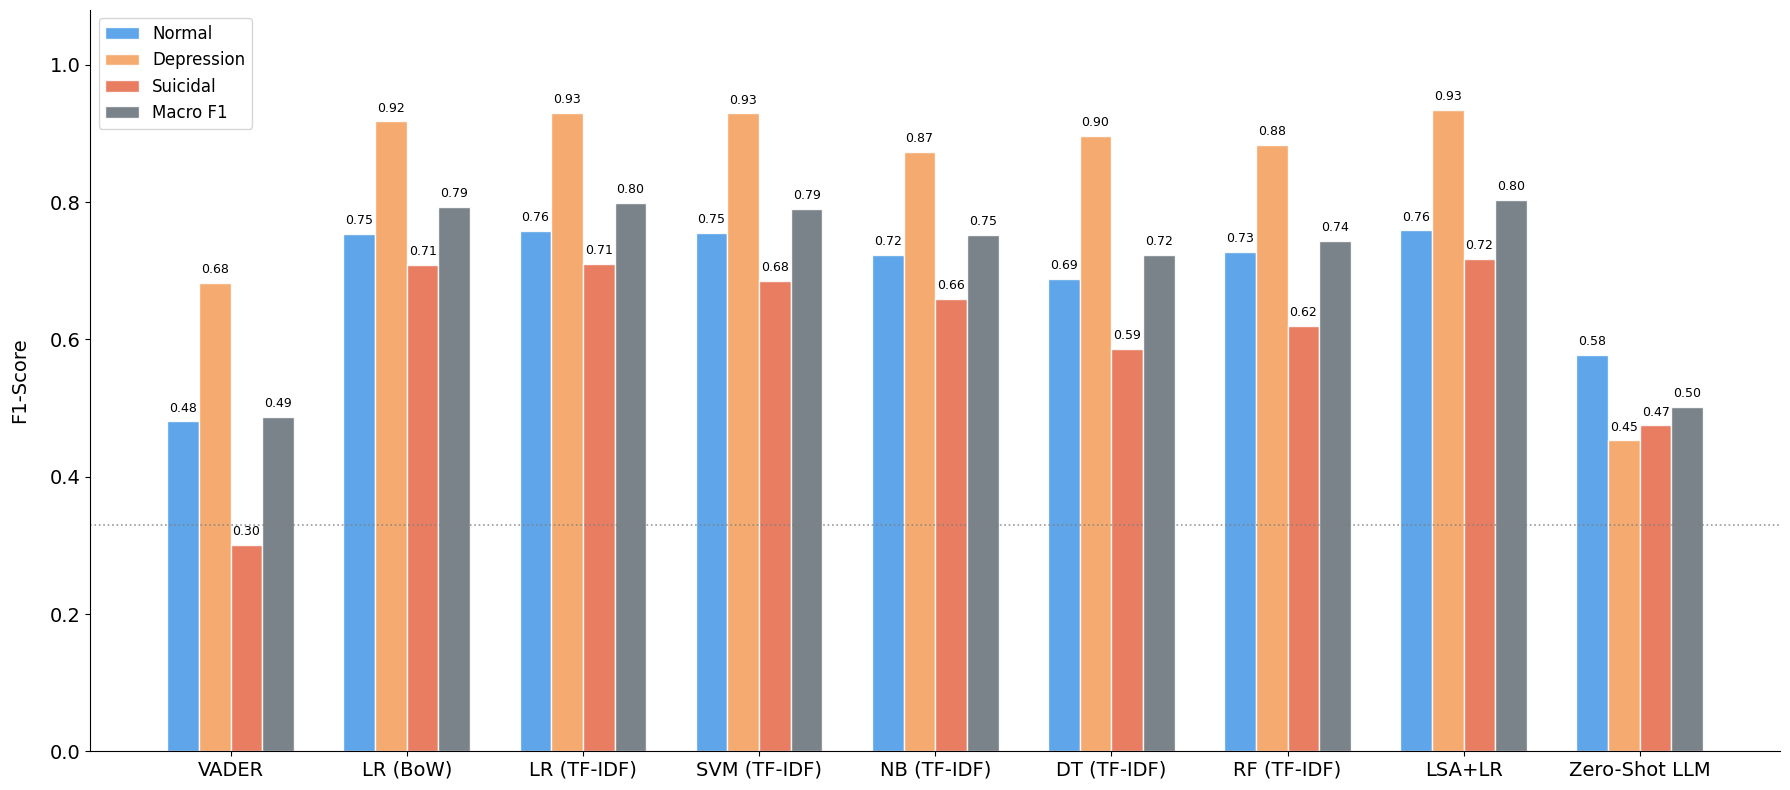

In [13]:
# ── Per-Class F1 Comparison ───────────────
macro_f1s  = [ALL_RESULTS[k]["macro_f1"]      for k in MODEL_ORDER]
normal_f1s = [ALL_RESULTS[k]["Normal_f1"]     for k in MODEL_ORDER]
dep_f1s    = [ALL_RESULTS[k]["Depression_f1"] for k in MODEL_ORDER]
sui_f1s    = [ALL_RESULTS[k]["Suicidal_f1"]   for k in MODEL_ORDER]

x = np.arange(len(MODEL_ORDER))
w = 0.18

fig, ax = plt.subplots(figsize=(18, 8))        # wider figure for 9 models
ax.bar(x-1.5*w, normal_f1s, w, label="Normal",    color=COLORS["Normal"],     alpha=0.9, edgecolor="white")
ax.bar(x-0.5*w, dep_f1s,    w, label="Depression", color=COLORS["Depression"], alpha=0.9, edgecolor="white")
ax.bar(x+0.5*w, sui_f1s,    w, label="Suicidal",   color=COLORS["Suicidal"],   alpha=0.9, edgecolor="white")
ax.bar(x+1.5*w, macro_f1s,  w, label="Macro F1",  color="#6C757D",             alpha=0.9, edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(MODEL_LABELS, fontsize=12)   # smaller font for 9 labels
ax.set_ylim(0, 1.08)
ax.set_ylabel("F1-Score", fontsize=14, labelpad=15)
ax.tick_params(axis='both', labelsize=14)
#ax.set_title("Figure 6 — Per-Class and Macro F1 Score by Model (Test Set)", fontsize=13, fontweight="bold", pad=12)
ax.legend(fontsize=12, loc="upper left")
ax.axhline(0.33, color="gray", linestyle=":", lw=1.2, alpha=0.8)   # fixed: 0.33 is random baseline for 3 classes
#ax.text(len(MODEL_ORDER)-0.6, 0.34, "random baseline", fontsize=10, color="gray")
ax.spines[["top","right"]].set_visible(False)

for i, vals in enumerate(zip(normal_f1s, dep_f1s, sui_f1s, macro_f1s)):
    for j, (val, off) in enumerate(zip(vals, [-1.5, -0.5, 0.5, 1.5])):
        ax.text(i+off*w, val+0.01, f"{val:.2f}",
                ha="center", va="bottom", fontsize=9)   # smaller annotation font

plt.tight_layout()
plt.savefig(OUT_DIR + "/fig6_f1_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

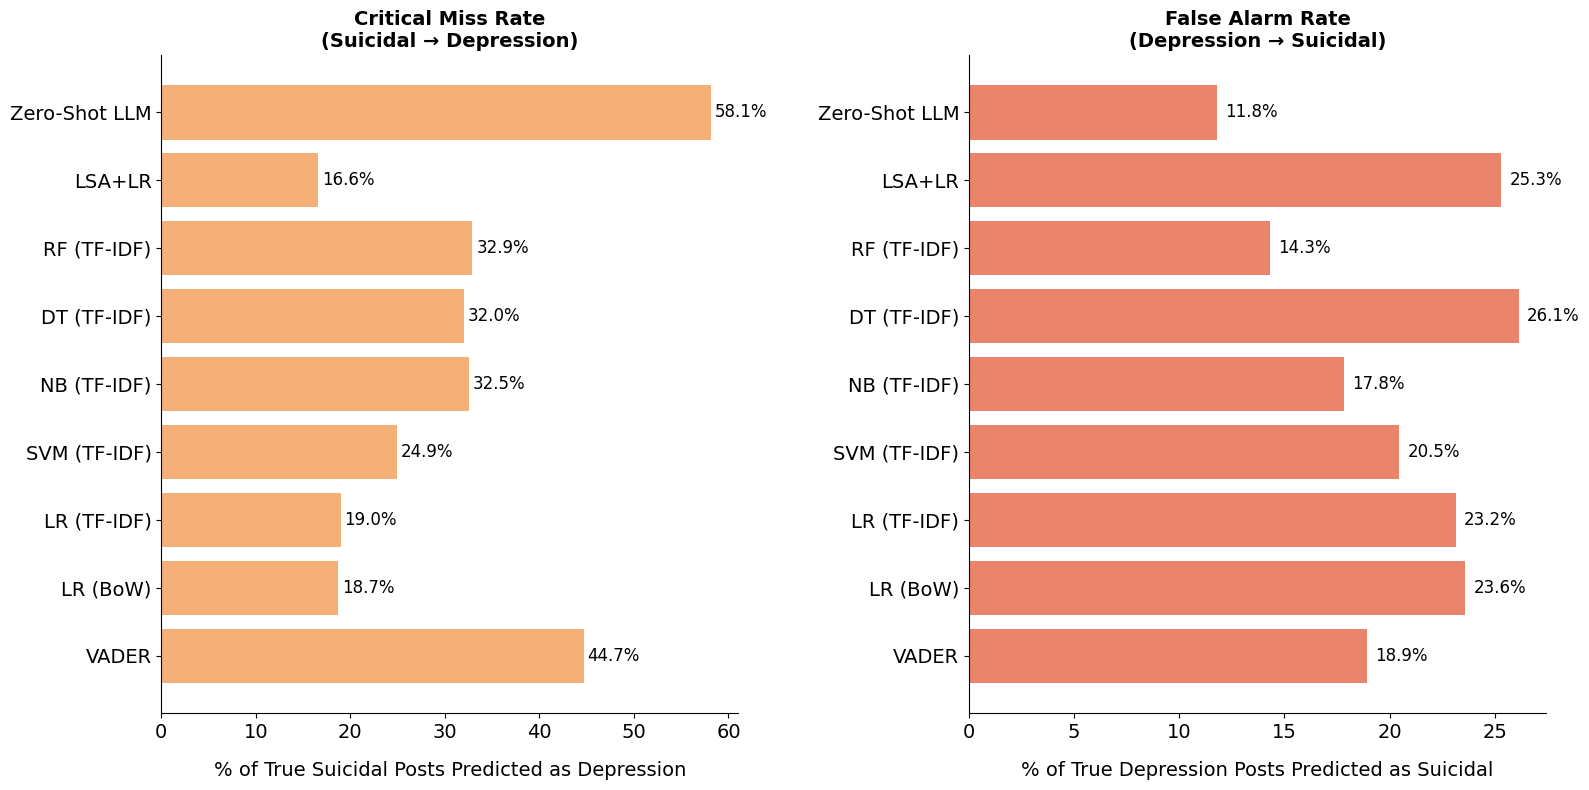

In [14]:
# ── Depression ↔ Suicidal Confusion ────────
sui_as_dep, dep_as_sui = [], []
for k in MODEL_ORDER:
    cm = ALL_CMS[k]
    ts = cm[2].sum(); td = cm[1].sum()
    sui_as_dep.append(cm[2,1] / ts * 100 if ts > 0 else 0)
    dep_as_sui.append(cm[1,2] / td * 100 if td > 0 else 0)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
y_pos = np.arange(len(MODEL_ORDER))

axes[0].barh(y_pos, sui_as_dep, color=COLORS["Depression"], alpha=0.85)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(MODEL_LABELS, fontsize=10)
axes[0].set_xlabel("% of True Suicidal Posts Predicted as Depression", fontsize=14, labelpad=14)
axes[0].set_title("Critical Miss Rate\n(Suicidal → Depression)", fontsize=14, fontweight="bold")
axes[0].tick_params(axis='both', labelsize=14)
axes[0].spines[["top","right"]].set_visible(False)
for i, v in enumerate(sui_as_dep):
    axes[0].text(v+0.4, i, f"{v:.1f}%", va="center", fontsize=12)

axes[1].barh(y_pos, dep_as_sui, color=COLORS["Suicidal"], alpha=0.85)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(MODEL_LABELS, fontsize=10)
axes[1].set_xlabel("% of True Depression Posts Predicted as Suicidal", fontsize=14, labelpad=14)
axes[1].set_title("False Alarm Rate\n(Depression → Suicidal)", fontsize=14, fontweight="bold")
axes[1].spines[["top","right"]].set_visible(False)
axes[1].tick_params(axis='both', labelsize=14)
for i, v in enumerate(dep_as_sui):
    axes[1].text(v+0.4, i, f"{v:.1f}%", va="center", fontsize=12)

#plt.suptitle("Figure 7 — Depression ↔ Suicidal Confusion Analysis", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.subplots_adjust(wspace=0.4)
plt.savefig(OUT_DIR + "/fig7_dep_sui_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# ── Results summary table ────────────────────────────
rows = []
for k, lbl in zip(MODEL_ORDER, MODEL_LABELS):
    r = ALL_RESULTS[k]
    rows.append({
        "Model":         lbl.replace("\n", " "),
        "Accuracy":      round(r["acc"],            3),
        "Macro F1":      round(r["macro_f1"],       3),
        "Normal F1":     round(r["Normal_f1"],      3),
        "Depression F1": round(r["Depression_f1"],  3),
        "Suicidal F1":   round(r["Suicidal_f1"],    3),
        "Sui→Dep (%)":   round(sui_as_dep[MODEL_ORDER.index(k)], 1),
        "Dep→Sui (%)":   round(dep_as_sui[MODEL_ORDER.index(k)], 1),
    })

results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))
#results_df.to_csv(OUT_DIR + "/phase2_results_summary.csv", index=False)

        Model  Accuracy  Macro F1  Normal F1  Depression F1  Suicidal F1  Sui→Dep (%)  Dep→Sui (%)
        VADER     0.534     0.488      0.481          0.682        0.300         44.7         18.9
     LR (BoW)     0.804     0.793      0.754          0.918        0.709         18.7         23.6
  LR (TF-IDF)     0.813     0.799      0.759          0.930        0.710         19.0         23.2
 SVM (TF-IDF)     0.807     0.790      0.755          0.929        0.685         24.9         20.5
  NB (TF-IDF)     0.762     0.752      0.723          0.874        0.659         32.5         17.8
  DT (TF-IDF)     0.744     0.724      0.688          0.896        0.586         32.0         26.1
  RF (TF-IDF)     0.769     0.744      0.727          0.884        0.620         32.9         14.3
       LSA+LR     0.816     0.804      0.759          0.935        0.717         16.6         25.3
Zero-Shot LLM     0.524     0.502      0.578          0.453        0.475         58.1         11.8


#**BERT MODEL**
**Note**: BERT models (based on Transformer architecture) involve large matrix operations that benefit heavily from parallel computation. Using a GPU can reduce training and inference time by an order of magnitude compared to CPU execution.

This section also uses the pre-split training and test data created and saved in earlier steps of the notebook.

In [3]:
import os, re, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score,
)

warnings.filterwarnings("ignore")

SEED = 42

def evaluate(name, y_true, y_pred):
    """Print report, store metrics and confusion matrix."""
    rep = classification_report(y_true, y_pred,
                                 target_names=LABEL_ORDER, output_dict=True)
    print(f"\n{'─'*55}")
    print(f"  {name}")
    print(f"{'─'*55}")
    print(classification_report(y_true, y_pred,
                                 target_names=LABEL_ORDER, digits=3))
    ALL_RESULTS[name] = {
        "acc":      accuracy_score(y_true, y_pred),
        "macro_f1": rep["macro avg"]["f1-score"],
        **{f"{c}_f1": rep[c]["f1-score"]   for c in LABEL_ORDER},
        **{f"{c}_p":  rep[c]["precision"]  for c in LABEL_ORDER},
        **{f"{c}_r":  rep[c]["recall"]     for c in LABEL_ORDER},
    }
    ALL_CMS[name] = confusion_matrix(y_true, y_pred, labels=LABEL_ORDER)

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

LABEL_ORDER = ["Normal", "Depression", "Suicidal"]
LABEL2ID    = {l: i for i, l in enumerate(LABEL_ORDER)}
ID2LABEL    = {i: l for l, i in LABEL2ID.items()}
COLORS      = {"Normal": "#4C9BE8", "Depression": "#F4A261", "Suicidal": "#E76F51"}
PALETTE     = [COLORS[l] for l in LABEL_ORDER]

OUT_DIR    = "/content/drive/MyDrive/BIOS735/Final/outputs"
SPLITS_DIR = OUT_DIR + "/splits"
CKPT_PATH  = OUT_DIR + "/bert_best512.pt"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"Memory : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU — go to Runtime → Change runtime type → T4 GPU")

Device : cuda
GPU    : Tesla T4
Memory : 15.6 GB


In [4]:
X_train = np.load(f"{SPLITS_DIR}/X_train_raw.npy", allow_pickle=True)
X_val   = np.load(f"{SPLITS_DIR}/X_val_raw.npy",   allow_pickle=True)
X_test  = np.load(f"{SPLITS_DIR}/X_test_raw.npy",  allow_pickle=True)
y_train = np.load(f"{SPLITS_DIR}/y_train.npy",     allow_pickle=True)
y_val   = np.load(f"{SPLITS_DIR}/y_val.npy",       allow_pickle=True)
y_test  = np.load(f"{SPLITS_DIR}/y_test.npy",      allow_pickle=True)

# ── Hyperparameters ────────────────────────
MODEL_NAME    = "bert-base-uncased"
MAX_LEN       = 512
BATCH_SIZE    = 16
EPOCHS        = 5
LR            = 1e-5
WARMUP_RATIO  = 0.1
WEIGHT_DECAY  = 0.01
MAX_GRAD_NORM = 1.0

class MentalHealthDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = [LABEL2ID[l] for l in labels]
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long),
        }

# ── Class weights (weighted cross-entropy) ─────────────
# Inverse-frequency weighting so Suicidal gets more gradient signal
counts  = np.array([(y_train == l).sum() for l in LABEL_ORDER], dtype=float)
weights = counts.sum() / (len(LABEL_ORDER) * counts)

# Manually boost Suicidal weight by 1.5x on top of inverse frequency
# This directly penalizes missing Suicidal posts more during training
SUICIDAL_BOOST = 1.5
weights[LABEL_ORDER.index("Suicidal")] *= SUICIDAL_BOOST

# Normalize so weights sum to number of classes (keeps loss scale stable)
weights = weights / weights.sum() * len(LABEL_ORDER)

class_weights = torch.tensor(weights, dtype=torch.float).to(DEVICE)

print("Class weights (inverse frequency + Suicidal boost):")
for l, w in zip(LABEL_ORDER, weights):
    print(f"  {l:12s}: {w:.4f}")


Class weights (inverse frequency + Suicidal boost):
  Normal      : 0.6877
  Depression  : 0.7296
  Suicidal    : 1.5827


In [5]:
def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

# ── Build tokenizer, datasets, dataloaders ────────────
print("Loading tokenizer …")
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

train_ds = MentalHealthDataset(X_train, y_train, tokenizer, MAX_LEN)
val_ds   = MentalHealthDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_ds  = MentalHealthDataset(X_test,  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    worker_init_fn=seed_worker,
    generator=g,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    worker_init_fn=seed_worker,
    generator=g,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    worker_init_fn=seed_worker,
    generator=g,
)

print(f"Train batches : {len(train_loader):,}")
print(f"Val batches   : {len(val_loader):,}")
print(f"Test batches  : {len(test_loader):,}")

Loading tokenizer …


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train batches : 1,855
Val batches   : 398
Test batches  : 398


In [6]:
# ── Build model, optimizer, scheduler ─────────────────
print("Loading BERT model …")
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABEL_ORDER),
    id2label=ID2LABEL,
    label2id=LABEL2ID,
).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)

# Separate weight decay: apply to weights but NOT to biases or LayerNorm
no_decay = ["bias", "LayerNorm.weight"]
optimizer_params = [
    {"params": [p for n, p in model.named_parameters()
                if not any(nd in n for nd in no_decay)],
     "weight_decay": WEIGHT_DECAY},
    {"params": [p for n, p in model.named_parameters()
                if any(nd in n for nd in no_decay)],
     "weight_decay": 0.0},
]
optimizer = torch.optim.AdamW(optimizer_params, lr=LR, eps=1e-8)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler    = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
scaler       = GradScaler(enabled=DEVICE.type == "cuda")

print(f"Total training steps : {total_steps:,}")
print(f"Warmup steps         : {warmup_steps:,}")

Loading BERT model …


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total training steps : 9,275
Warmup steps         : 927


In [7]:
# ── Training & validation functions ────────────────────
def train_epoch(model, loader, optimizer, scheduler, criterion, scaler):
    model.train()
    total_loss, total_correct, total_n = 0.0, 0, 0

    for batch in loader:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels         = batch["label"].to(DEVICE)

        optimizer.zero_grad()
        with autocast(enabled=DEVICE.type == "cuda"):
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss    = criterion(outputs.logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        preds          = outputs.logits.argmax(dim=-1)
        total_loss    += loss.item() * labels.size(0)
        total_correct += (preds == labels).sum().item()
        total_n       += labels.size(0)

    return total_loss / total_n, total_correct / total_n


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []

    for batch in loader:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels         = batch["label"].to(DEVICE)

        with autocast(enabled=DEVICE.type == "cuda"):
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss    = criterion(outputs.logits, labels)

        total_loss += loss.item() * labels.size(0)
        all_preds.extend(outputs.logits.argmax(dim=-1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    n   = len(all_labels)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average="macro")
    return total_loss / n, acc, f1, np.array(all_preds), np.array(all_labels)

In [9]:
# ── Fine-tuning loop ───────────────────────────────────
print("=" * 55)
print("  BERT Fine-Tuning")
print("=" * 55)

history     = defaultdict(list)
best_val_f1 = -1.0
best_epoch  = -1

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = train_epoch(
        model, train_loader, optimizer, scheduler, criterion, scaler)
    val_loss, val_acc, val_f1, _, _ = eval_epoch(
        model, val_loader, criterion)

    elapsed = time.time() - t0

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    print(f"\n  Epoch {epoch}/{EPOCHS}  ({elapsed:.0f}s)")
    print(f"    train loss={train_loss:.4f}  train acc={train_acc:.3f}")
    print(f"    val   loss={val_loss:.4f}  val   acc={val_acc:.3f}  val macro F1={val_f1:.3f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch  = epoch
        torch.save(model.state_dict(), CKPT_PATH)
        print(f"    ✓ New best — checkpoint saved")

print(f"\nTraining complete.")
print(f"Best val macro F1 : {best_val_f1:.3f} at epoch {best_epoch}")
print(f"Checkpoint saved  : {CKPT_PATH}")

  BERT Fine-Tuning

  Epoch 1/5  (876s)
    train loss=0.5650  train acc=0.739
    val   loss=0.3811  val   acc=0.831  val macro F1=0.819
    ✓ New best — checkpoint saved

  Epoch 2/5  (880s)
    train loss=0.3377  train acc=0.863
    val   loss=0.3537  val   acc=0.852  val macro F1=0.841
    ✓ New best — checkpoint saved

  Epoch 3/5  (880s)
    train loss=0.2652  train acc=0.898
    val   loss=0.3878  val   acc=0.850  val macro F1=0.839

  Epoch 4/5  (880s)
    train loss=0.2068  train acc=0.928
    val   loss=0.5262  val   acc=0.854  val macro F1=0.840

  Epoch 5/5  (879s)
    train loss=0.1641  train acc=0.944
    val   loss=0.5768  val   acc=0.854  val macro F1=0.841
    ✓ New best — checkpoint saved

Training complete.
Best val macro F1 : 0.841 at epoch 5
Checkpoint saved  : /content/drive/MyDrive/BIOS735/Final/outputs/bert_best512.pt


In [12]:
# ── Load best checkpoint & evaluate on test set ───────
print("Loading best checkpoint …")
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))

_, _, _, preds_arr, labels_arr = eval_epoch(model, test_loader, criterion)
preds_bert = np.array([ID2LABEL[p] for p in preds_arr])

print(f"\n{'─'*55}")
print("  BERT — Test Set Results")
print(f"{'─'*55}")
print(classification_report(y_test, preds_bert, target_names=LABEL_ORDER, digits=3))

np.save(f"{SPLITS_DIR}/preds_bert512.npy", preds_bert) # Save predictions

Loading best checkpoint …

───────────────────────────────────────────────────────
  BERT — Test Set Results
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

      Normal      0.850     0.776     0.811      2311
  Depression      0.970     0.980     0.975      2451
    Suicidal      0.718     0.797     0.755      1598

    accuracy                          0.860      6360
   macro avg      0.846     0.851     0.847      6360
weighted avg      0.863     0.860     0.860      6360



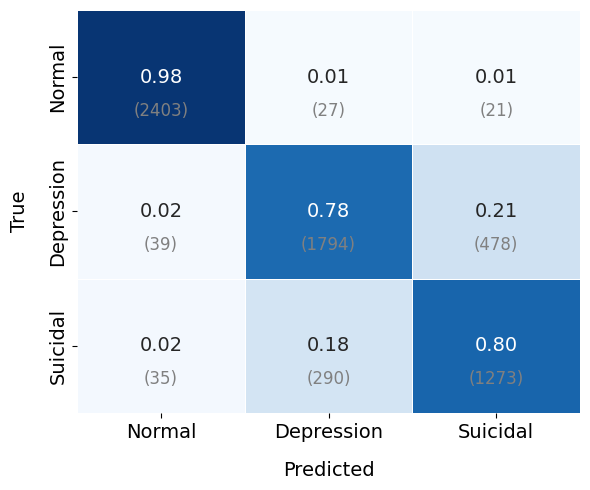

In [11]:
# ── BERT confusion matrix ─────────────────
cm      = confusion_matrix(y_test, preds_bert, labels=LABEL_ORDER)
rs      = cm.sum(axis=1, keepdims=True)
cm_norm = np.where(rs > 0, cm.astype(float) / rs, 0)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER,
            ax=ax, cbar=False, linewidths=0.5, vmin=0, vmax=1, annot_kws={"size": 14})
for i in range(3):
    for j in range(3):
        ax.text(j+0.5, i+0.75, f"({cm[i,j]})",
                ha="center", va="center", fontsize=12, color="gray")
#ax.set_title("Figure 9 — BERT Confusion Matrix (Test Set, Row-Normalised)", fontsize=11, fontweight="bold")
ax.set_xlabel("Predicted", fontsize=14, labelpad=14)
ax.set_ylabel("True",      fontsize=14, labelpad=14)
ax.tick_params(axis='both', labelsize=14)
plt.tight_layout()
plt.savefig(OUT_DIR + "/bert_confusion512.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# ── Full results summary table ───────────────────────
rows = []
for name, macro, norm, dep, sui in zip(all_names, all_macro,
                                        all_normal, all_dep, all_sui):
    rows.append({
        "Model":         name,
        "Macro F1":      round(macro, 3),
        "Normal F1":     round(norm,  3),
        "Depression F1": round(dep,   3),
        "Suicidal F1":   round(sui,   3),
    })

results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))
results_df.to_csv(OUT_DIR + "/BERT_phase3_results_summary512.csv", index=False)

        Model  Macro F1  Normal F1  Depression F1  Suicidal F1
        VADER     0.488      0.481          0.682        0.300
     LR (BoW)     0.794      0.753          0.918        0.710
  LR (TF-IDF)     0.801      0.760          0.931        0.711
 SVM (TF-IDF)     0.788      0.754          0.928        0.682
  NB (TF-IDF)     0.753      0.724          0.875        0.658
  DT (TF-IDF)     0.725      0.694          0.894        0.588
  RF (TF-IDF)     0.745      0.730          0.882        0.624
       LSA+LR     0.804      0.760          0.934        0.719
Zero-Shot LLM     0.502      0.578          0.453        0.475
         BERT     0.847      0.811          0.975        0.755


##**OOD ROBUSTNESS CHECK & QUALITATIVE**

In [15]:
import os, re, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast
from transformers import BertTokenizerFast, BertForSequenceClassification
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from nltk.stem.snowball import SnowballStemmer
from collections import Counter

warnings.filterwarnings("ignore")
np.random.seed(42)
torch.manual_seed(42)

LABEL_ORDER = ["Normal", "Depression", "Suicidal"]
LABEL2ID    = {l: i for i, l in enumerate(LABEL_ORDER)}
ID2LABEL    = {i: l for l, i in LABEL2ID.items()}
COLORS      = {"Normal": "#4C9BE8", "Depression": "#F4A261", "Suicidal": "#E76F51"}
PALETTE     = [COLORS[l] for l in LABEL_ORDER]

OUT_DIR    = "/content/drive/MyDrive/BIOS735/Final/outputs"
SPLITS_DIR = OUT_DIR + "/splits"
CKPT_PATH  = OUT_DIR + "/bert_best512.pt"
DATA_FULL  = "/content/drive/MyDrive/BIOS735/Final/Combined Data.csv"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

Device : cuda
GPU    : Tesla T4


In [16]:
# ── Load splits & BERT v2 predictions ─────────────────
X_test  = np.load(f"{SPLITS_DIR}/X_test_raw.npy", allow_pickle=True)
y_test  = np.load(f"{SPLITS_DIR}/y_test.npy",     allow_pickle=True)
y_train = np.load(f"{SPLITS_DIR}/y_train.npy",    allow_pickle=True)

preds_bert = np.load(f"{SPLITS_DIR}/preds_bert512.npy", allow_pickle=True)

print(f"Test set    : {len(y_test):,} posts")
print(f"BERT preds  : {len(preds_bert):,} ✓")

Test set    : 6,360 posts
BERT preds  : 6,360 ✓


In [18]:
# ── Reload BERT model for inference ────────────────────
MAX_LEN    = 512
BATCH_SIZE = 16
MODEL_NAME = "bert-base-uncased"

print("Loading tokenizer and model …")
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)
model     = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABEL_ORDER),
    id2label=ID2LABEL,
    label2id=LABEL2ID,
).to(DEVICE)
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()
print("BERT v2 loaded ✓")


# Reusable inference function
class TextDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len):
        self.texts     = texts
        self.tokenizer = tokenizer
        self.max_len   = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]), max_length=self.max_len,
            padding="max_length", truncation=True, return_tensors="pt")
        return {"input_ids":      enc["input_ids"].squeeze(0),
                "attention_mask": enc["attention_mask"].squeeze(0)}

@torch.no_grad()
def predict(texts, batch_size=64):
    ds     = TextDataset(texts, tokenizer, MAX_LEN)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False,
                        num_workers=2, pin_memory=True)
    preds  = []
    for batch in loader:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        with autocast(enabled=DEVICE.type == "cuda"):
            logits = model(input_ids=input_ids,
                           attention_mask=attention_mask).logits
        preds.extend(logits.argmax(dim=-1).cpu().numpy())
    return np.array([ID2LABEL[p] for p in preds])

print("Inference function ready ✓")

Loading tokenizer and model …


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT v2 loaded ✓
Inference function ready ✓


In [20]:
# ── PERFORMANCE BY TEXT LENGTH ────────────────────────
print("=" * 55)
print("  Phase 4 — Performance by Text Length")
print("=" * 55)

word_counts = np.array([len(str(t).split()) for t in X_test])
median_wc   = int(np.median(word_counts))
print(f"Median word count (test set): {median_wc} words")

short_mask = word_counts <= median_wc
long_mask  = ~short_mask
print(f"Short posts (≤{median_wc} words): {short_mask.sum():,}")
print(f"Long posts  (>{median_wc} words): {long_mask.sum():,}")

# Run inference on each subset
print("\nRunning BERT inference on short posts …")
preds_short = predict(X_test[short_mask])
print("Running BERT inference on long posts …")
preds_long  = predict(X_test[long_mask])

rep_short = classification_report(y_test[short_mask], preds_short,
                                   target_names=LABEL_ORDER, output_dict=True)
rep_long  = classification_report(y_test[long_mask],  preds_long,
                                   target_names=LABEL_ORDER, output_dict=True)

print(f"\nShort posts (≤{median_wc} words, n={short_mask.sum():,}):")
print(classification_report(y_test[short_mask], preds_short,
                              target_names=LABEL_ORDER, digits=3))
print(f"Long posts (>{median_wc} words, n={long_mask.sum():,}):")
print(classification_report(y_test[long_mask],  preds_long,
                              target_names=LABEL_ORDER, digits=3))

  Phase 4 — Performance by Text Length
Median word count (test set): 47 words
Short posts (≤47 words): 3,192
Long posts  (>47 words): 3,168

Running BERT inference on short posts …
Running BERT inference on long posts …

Short posts (≤47 words, n=3,192):
              precision    recall  f1-score   support

      Normal      0.809     0.708     0.755       514
  Depression      0.973     0.981     0.977      2223
    Suicidal      0.718     0.789     0.752       455

    accuracy                          0.910      3192
   macro avg      0.833     0.826     0.828      3192
weighted avg      0.910     0.910     0.909      3192

Long posts (>47 words, n=3,168):
              precision    recall  f1-score   support

      Normal      0.861     0.796     0.827      1797
  Depression      0.945     0.974     0.959       228
    Suicidal      0.719     0.800     0.757      1143

    accuracy                          0.810      3168
   macro avg      0.841     0.856     0.848      3168
weigh

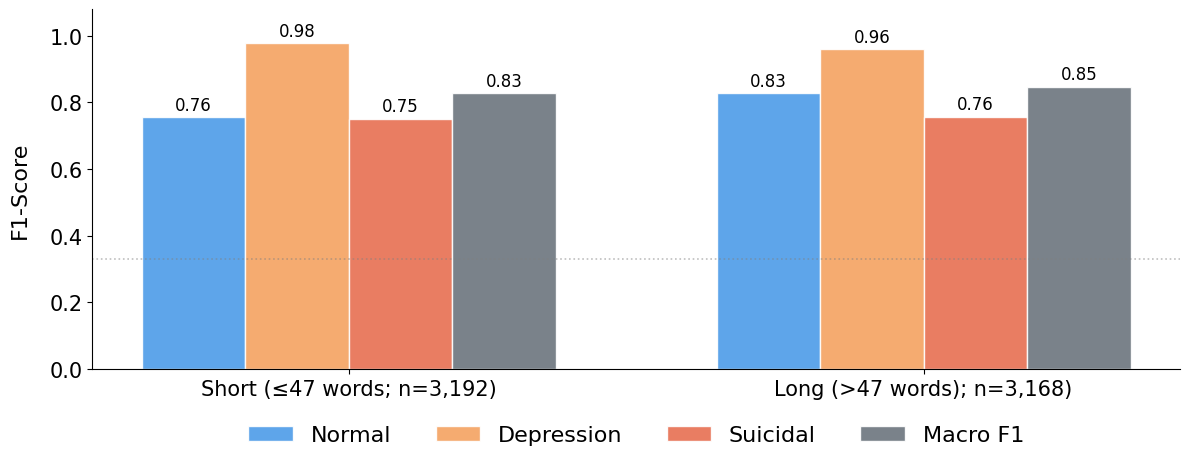

In [80]:
# ── Figure — Performance by text length ───────────────
groups   = [f"Short (≤{median_wc} words; n={short_mask.sum():,})",
            f"Long (>{median_wc} words); n={long_mask.sum():,})"]
reps     = [rep_short, rep_long]

macro_f1s  = [r["macro avg"]["f1-score"]  for r in reps]
normal_f1s = [r["Normal"]["f1-score"]     for r in reps]
dep_f1s    = [r["Depression"]["f1-score"] for r in reps]
sui_f1s    = [r["Suicidal"]["f1-score"]   for r in reps]

x = np.arange(2); w = 0.18
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x-1.5*w, normal_f1s, w, label="Normal",     color=COLORS["Normal"],     alpha=0.9, edgecolor="white")
ax.bar(x-0.5*w, dep_f1s,    w, label="Depression", color=COLORS["Depression"], alpha=0.9, edgecolor="white")
ax.bar(x+0.5*w, sui_f1s,    w, label="Suicidal",   color=COLORS["Suicidal"],   alpha=0.9, edgecolor="white")
ax.bar(x+1.5*w, macro_f1s,  w, label="Macro F1",   color="#6C757D",            alpha=0.9, edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(groups, fontsize=10)

ax.set_xlabel(" ", fontsize=14, labelpad=14)
ax.set_ylabel("F1-Score", fontsize=16, labelpad=14)

ax.set_ylim(0, 1.08)
ax.spines[["top", "right"]].set_visible(False)
ax.axhline(0.33, color="gray", linestyle=":", lw=1.2, alpha=0.5)

# Move legend below figure
ax.legend(
    fontsize=16,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=4,
    frameon=False
)

for i, vals in enumerate(zip(normal_f1s, dep_f1s, sui_f1s, macro_f1s)):
    for val, off in zip(vals, [-1.5, -0.5, 0.5, 1.5]):
        ax.text(i + off*w, val + 0.01, f"{val:.2f}", ha="center", va="bottom", fontsize=12)

ax.tick_params(axis='both', labelsize=15)

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)   # extra room for legend below
plt.savefig(OUT_DIR + "/fig_length_analysis512.png", dpi=150, bbox_inches="tight")
plt.show()

In [22]:
print("=" * 55)
print("  OOD Robustness Testing")
print("=" * 55)

OOD_PATH = "/content/drive/MyDrive/BIOS735/Final/ood.csv"
df_ood   = pd.read_csv(OOD_PATH)
df_ood   = df_ood.rename(columns={"statement": "text", "status": "label"})
df_ood   = df_ood.dropna(subset=["text"])
df_ood["text"]  = df_ood["text"].astype(str)
df_ood["label"] = df_ood["label"].str.strip()

OOD_CLASSES = ["Anxiety", "Bipolar", "Stress", "Personality disorder"]

print(f"OOD posts: {len(df_ood):,}")
for cls in OOD_CLASSES:
    n = (df_ood["label"] == cls).sum()
    print(f"  {cls:25s}: {n:,}")

  OOD Robustness Testing
OOD posts: 10,282
  Anxiety                  : 3,841
  Bipolar                  : 2,777
  Stress                   : 2,587
  Personality disorder     : 1,077


In [23]:
def preprocess_transformer(text):
    text = str(text).encode("ascii", "ignore").decode("ascii")
    text = re.sub(r"http\S+|www\S+", " ", text)
    return re.sub(r"\s+", " ", text).strip()

df_ood["text_clean"] = df_ood["text"].apply(preprocess_transformer)

print("Running BERT inference on OOD posts …")
preds_ood        = predict(df_ood["text_clean"].values)
df_ood["bert_pred"] = preds_ood

print("\nOOD prediction breakdown per class:")
ood_results = {}
for cls in OOD_CLASSES:
    mask  = df_ood["label"] == cls
    total = mask.sum()
    cls_preds = preds_ood[mask.values]
    rates = {l: (cls_preds == l).sum() / total * 100 for l in LABEL_ORDER}
    ood_results[cls] = rates
    print(f"\n  {cls} (n={total:,}):")
    for l, r in rates.items():
        print(f"    → {l:12s}: {r:.1f}%")

# Save OOD results
ood_rows = []
for cls in OOD_CLASSES:
    row = {"OOD Class": cls}
    row.update({f"→ {l} (%)": round(ood_results[cls][l], 1)
                for l in LABEL_ORDER})
    ood_rows.append(row)
ood_df = pd.DataFrame(ood_rows)
print("\nSummary table:")
print(ood_df.to_string(index=False))
ood_df.to_csv(OUT_DIR + "/phase4_ood_results512.csv", index=False)

Running BERT inference on OOD posts …

OOD prediction breakdown per class:

  Anxiety (n=3,841):
    → Normal      : 29.9%
    → Depression  : 69.2%
    → Suicidal    : 0.9%

  Bipolar (n=2,777):
    → Normal      : 14.9%
    → Depression  : 83.9%
    → Suicidal    : 1.2%

  Stress (n=2,587):
    → Normal      : 50.6%
    → Depression  : 47.7%
    → Suicidal    : 1.7%

  Personality disorder (n=1,077):
    → Normal      : 24.0%
    → Depression  : 74.7%
    → Suicidal    : 1.4%

Summary table:
           OOD Class  → Normal (%)  → Depression (%)  → Suicidal (%)
             Anxiety          29.9              69.2             0.9
             Bipolar          14.9              83.9             1.2
              Stress          50.6              47.7             1.7
Personality disorder          24.0              74.7             1.4


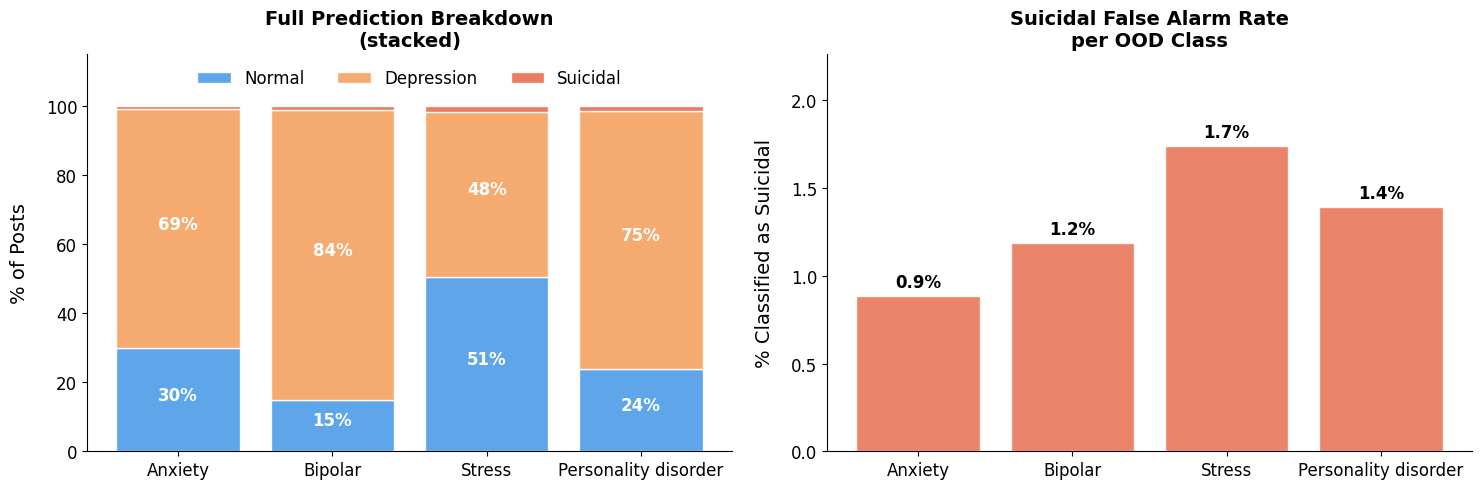

In [74]:
# ── Figure — OOD robustness ───────────────────────────
norm_rates = [ood_results[c]["Normal"]     for c in OOD_CLASSES]
dep_rates  = [ood_results[c]["Depression"] for c in OOD_CLASSES]
sui_rates  = [ood_results[c]["Suicidal"]   for c in OOD_CLASSES]

x = np.arange(len(OOD_CLASSES))
w = 0.25

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left — stacked bar showing full prediction breakdown
bottom_dep = np.array(norm_rates)
bottom_sui = bottom_dep + np.array(dep_rates)

axes[0].bar(x, norm_rates, color=COLORS["Normal"],     alpha=0.9,
            edgecolor="white", label="Normal")
axes[0].bar(x, dep_rates,  color=COLORS["Depression"], alpha=0.9,
            edgecolor="white", label="Depression", bottom=norm_rates)
axes[0].bar(x, sui_rates,  color=COLORS["Suicidal"],   alpha=0.9,
            edgecolor="white", label="Suicidal",   bottom=bottom_sui)

axes[0].set_xticks(x)
axes[0].set_xticklabels(OOD_CLASSES, fontsize=12)
axes[0].set_ylabel("% of Posts", fontsize=14, labelpad = 12)
axes[0].set_ylim(0, 115)
axes[0].set_title("Full Prediction Breakdown\n(stacked)", fontsize=14, fontweight="bold")
axes[0].legend(fontsize=12, loc="upper center", ncol=3, frameon=False)
axes[0].spines[["top","right"]].set_visible(False)
axes[0].tick_params(axis='both', labelsize=12)
for i, (n, d, s) in enumerate(zip(norm_rates, dep_rates, sui_rates)):
    if n > 4: axes[0].text(i, n/2,       f"{n:.0f}%", ha="center", fontsize=12,
                            color="white", fontweight="bold")
    if d > 4: axes[0].text(i, n+d/2,     f"{d:.0f}%", ha="center", fontsize=12,
                            color="white", fontweight="bold")
    if s > 4: axes[0].text(i, n+d+s/2,   f"{s:.0f}%", ha="center", fontsize=12,
                            color="white", fontweight="bold")

# Right — focus on Suicidal false alarm rate only (most clinically relevant)
axes[1].bar(x, sui_rates, color=COLORS["Suicidal"], alpha=0.85, edgecolor="white")
axes[1].set_xticks(x)
axes[1].set_xticklabels(OOD_CLASSES, fontsize=12)
axes[1].set_ylabel("% Classified as Suicidal", fontsize=14, labelpad = 12)
axes[1].set_ylim(0, max(sui_rates) * 1.3)
axes[1].set_title("Suicidal False Alarm Rate\nper OOD Class", fontsize=14,
                   fontweight="bold")
axes[1].spines[["top","right"]].set_visible(False)
axes[1].tick_params(axis='both', labelsize=12)
for i, v in enumerate(sui_rates):
    axes[1].text(i, v+0.05, f"{v:.1f}%", ha="center", fontsize=12, fontweight="bold")

#plt.suptitle("OOD Robustness: wellBERT Predictions on Non-Target Classes", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR + "/fig_ood_robustness512.png", dpi=150, bbox_inches="tight")
plt.show()

In [25]:
# ── QUALITATIVE ERROR ANALYSIS ───────────────────────
print("=" * 55)
print("  Phase 4 — Qualitative Error Analysis")
print("=" * 55)

N_PER_PAIR = 8   # examples to collect per confusion pair

error_rows = []
for true_cls in LABEL_ORDER:
    for pred_cls in LABEL_ORDER:
        if true_cls == pred_cls:
            continue
        mask    = (y_test == true_cls) & (preds_bert == pred_cls)
        indices = np.where(mask)[0]
        for idx in indices[:N_PER_PAIR]:
            error_rows.append({
                "true_label":  true_cls,
                "pred_label":  pred_cls,
                "text":        X_test[idx],
                "word_count":  len(str(X_test[idx]).split()),
            })

errors_df = pd.DataFrame(error_rows)
errors_df.to_csv(OUT_DIR + "/phase4_error_analysis512.csv", index=False)

print(f"Total error examples collected: {len(errors_df)}")
print("\nError counts per confusion pair:")
pair_counts = errors_df.groupby(["true_label","pred_label"]).size().reset_index(name="count")
print(pair_counts.to_string(index=False))

  Phase 4 — Qualitative Error Analysis
Total error examples collected: 48

Error counts per confusion pair:
true_label pred_label  count
Depression     Normal      8
Depression   Suicidal      8
    Normal Depression      8
    Normal   Suicidal      8
  Suicidal Depression      8
  Suicidal     Normal      8


In [26]:
# ── Display key error examples ───────────────────────
# 1. Suicidal predicted as Depression (critical miss)
# 2. Depression predicted as Suicidal (false alarm)

for true_cls, pred_cls in [("Suicidal", "Depression"),
                             ("Depression", "Suicidal")]:
    subset = errors_df[
        (errors_df["true_label"] == true_cls) &
        (errors_df["pred_label"] == pred_cls)
    ].head(5)

    print(f"\n{'═'*60}")
    print(f"  TRUE: {true_cls}  →  PREDICTED: {pred_cls}")
    print(f"{'═'*60}")
    for i, row in subset.iterrows():
        print(f"\n  [{row['word_count']} words]")
        print(f"  {str(row['text'])[:250]}")
        print(f"  {'─'*50}")


════════════════════════════════════════════════════════════
  TRUE: Suicidal  →  PREDICTED: Depression
════════════════════════════════════════════════════════════

  [14 words]
  I want to kill myself I really want to fucking kill myself im done
  ──────────────────────────────────────────────────

  [448 words]
  I am having one these shitty day's now and I am just going to express it before I forget it.IDK why every moment I am thinking of ways to "magical disappear from this world" without hurting anyone's feeling. For an example, my family; they mean every
  ──────────────────────────────────────────────────

  [60 words]
  I am not a good son, I am not a good brother, I am not a good friend, I am not a good person, I only exist to ruin everything. I crave the feeling of nothing at all, I wish I could have never existed, then maybe I would not have turned out this way. 
  ──────────────────────────────────────────────────

  [87 words]
  A rainbow baby is the baby you have after

In [2]:
import torch
import time
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizerFast, BertForSequenceClassification
from torch.cuda.amp import autocast

# ── Config ────────────────────────────────────────────
SEED        = 42
MODEL_NAME  = "bert-base-uncased"
MAX_LEN     = 512
BATCH_SIZE  = 16
CKPT_PATH   = "/content/drive/MyDrive/BIOS735/Final/outputs/bert_best512.pt"
SPLITS_DIR  = "/content/drive/MyDrive/BIOS735/Final/outputs/splits"
LABEL_ORDER = ["Normal", "Depression", "Suicidal"]
LABEL2ID    = {l: i for i, l in enumerate(LABEL_ORDER)}
ID2LABEL    = {i: l for l, i in LABEL2ID.items()}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
print(f"GPU    : {torch.cuda.get_device_name(0)}")

# ── Load test set ─────────────────────────────────────
X_test = np.load(f"{SPLITS_DIR}/X_test_raw.npy", allow_pickle=True)
y_test = np.load(f"{SPLITS_DIR}/y_test.npy",     allow_pickle=True)
print(f"Test set: {len(X_test):,} posts")

# ── Dataset ───────────────────────────────────────────
class TextDataset(Dataset):
    def __init__(self, texts, tokenizer):
        self.texts = texts
        self.tok   = tokenizer
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tok(
            str(self.texts[idx]),
            max_length=MAX_LEN,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
        }

# ── Load model and tokenizer ──────────────────────────
print("\nLoading tokenizer and model ...")
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)
model     = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABEL_ORDER),
    id2label=ID2LABEL,
    label2id=LABEL2ID,
).to(DEVICE)

model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()
print("Checkpoint loaded ✓")

# ── Warmup (GPU needs a few batches to reach full speed) ──
print("\nWarming up GPU ...")
warmup_ds     = TextDataset(X_test[:64], tokenizer)
warmup_loader = DataLoader(warmup_ds, batch_size=BATCH_SIZE, shuffle=False)

with torch.no_grad():
    for batch in warmup_loader:
        with autocast(enabled=DEVICE.type == "cuda"):
            _ = model(
                input_ids      = batch["input_ids"].to(DEVICE),
                attention_mask = batch["attention_mask"].to(DEVICE)
            ).logits
print("Warmup done ✓")

# ── Inference benchmark ───────────────────────────────
print("\nRunning inference on full test set ...")
ds     = TextDataset(X_test, tokenizer)
loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=2, pin_memory=True)

all_preds = []
torch.cuda.synchronize()
t0 = time.time()

with torch.no_grad():
    for batch in loader:
        with autocast(enabled=DEVICE.type == "cuda"):
            logits = model(
                input_ids      = batch["input_ids"].to(DEVICE),
                attention_mask = batch["attention_mask"].to(DEVICE)
            ).logits
        all_preds.extend(logits.argmax(dim=-1).cpu().numpy())

torch.cuda.synchronize()
infer_time = time.time() - t0

preds_bert = np.array([ID2LABEL[p] for p in all_preds])

# ── Results ───────────────────────────────────────────
throughput = len(X_test) / infer_time

print(f"\n{'='*55}")
print(f"  WellBERT Inference Benchmark")
print(f"{'='*55}")
print(f"  Test set size  : {len(X_test):,} posts")
print(f"  Total time     : {infer_time:.2f}s")
print(f"  Throughput     : {throughput:.0f} posts/sec")
print(f"  Latency        : {infer_time/len(X_test)*1000:.2f} ms/post")

Device : cuda
GPU    : Tesla T4
Test set: 6,360 posts

Loading tokenizer and model ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Checkpoint loaded ✓

Warming up GPU ...


/tmp/ipykernel_2948/1492811167.py:68: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=DEVICE.type == "cuda"):


Warmup done ✓

Running inference on full test set ...


/tmp/ipykernel_2948/1492811167.py:87: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=DEVICE.type == "cuda"):



  WellBERT Inference Benchmark
  Test set size  : 6,360 posts
  Total time     : 45.01s
  Throughput     : 141 posts/sec
  Latency        : 7.08 ms/post
